In [40]:
# ╔══════════════════════════════════════════════════════════════╗
# ║           MASTER SETUP CELL — RUN THIS FIRST                ║
# ║     Run this cell after every kernel restart                 ║
# ╚══════════════════════════════════════════════════════════════╝

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

# ── Paths ────────────────────────────────────────────────────────
BASE_DIR    = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR    = os.path.join(BASE_DIR, 'data', 'raw')
IMAGE_DIR   = os.path.join(DATA_DIR, 'images', 'Finger Joints')
LABELS_PATH = os.path.join(DATA_DIR, 'hand.xlsx')
REPORTS_DIR = os.path.join(BASE_DIR, 'reports')
SPLITS_DIR  = os.path.join(BASE_DIR, 'data', 'splits')

# Relative image path from project root — works on any machine
RELATIVE_IMAGE_DIR = os.path.join('data', 'raw', 'images', 'Finger Joints')

# ── Fix image paths to relative ──────────────────────────────────
# Run once — converts absolute paths to relative in all CSV files
for csv_name in ['master_dataset.csv', 'train.csv', 'val.csv', 'test.csv']:
    csv_path = os.path.join(SPLITS_DIR, csv_name)
    df_fix   = pd.read_csv(csv_path)
    
    # Only fix if paths are still absolute (contain drive letter or /)
    sample_path = str(df_fix['image_path'].iloc[0])
    if os.path.isabs(sample_path) or ':' in sample_path:
        df_fix['image_path'] = df_fix['image_path'].apply(
            lambda x: os.path.join(
                RELATIVE_IMAGE_DIR, os.path.basename(x)
            )
        )
        df_fix.to_csv(csv_path, index=False)
        print(f"Fixed {csv_name} → {df_fix['image_path'].iloc[0]}")
    else:
        print(f"Already relative — {csv_name} → {sample_path}")

# ── Constants ────────────────────────────────────────────────────
# ── Constants ────────────────────────────────────────────────────
FINAL_JOINTS = ['dip2', 'dip3', 'dip4', 'dip5']

KL_COLS_MAP = {
    'dip2': 'v00DIP2_KL',
    'dip3': 'v00DIP3_KL',
    'dip4': 'v00DIP4_KL',
    'dip5': 'v00DIP5_KL',
}

N_CLASSES = 5   # grades 0, 1, 2, 3, 4 — no merging
IMAGE_SIZE    = 180
DATASET_MEAN  = 0.2361
DATASET_STD   = 0.2095
N_CLASSES     = 5
BATCH_SIZE    = 32
CLASS_WEIGHTS = [0.3071, 1.5089, 1.0551, 13.3525, 17.1852]


# ── Load raw Excel ───────────────────────────────────────────────
df = pd.read_excel(LABELS_PATH)
print(f"df loaded              : {df.shape}")

# ── Load master dataset ──────────────────────────────────────────
valid_df = pd.read_csv(os.path.join(SPLITS_DIR, 'master_dataset.csv'))
print(f"valid_df loaded        : {valid_df.shape}")

# ── Load splits if they exist ────────────────────────────────────
train_path = os.path.join(SPLITS_DIR, 'train.csv')
val_path   = os.path.join(SPLITS_DIR, 'val.csv')
test_path  = os.path.join(SPLITS_DIR, 'test.csv')

if os.path.exists(train_path):
    train_df = pd.read_csv(train_path)
    val_df   = pd.read_csv(val_path)
    test_df  = pd.read_csv(test_path)
    print(f"train_df loaded        : {train_df.shape}")
    print(f"val_df loaded          : {val_df.shape}")
    print(f"test_df loaded         : {test_df.shape}")
else:
    print("Splits not yet created — run splitting pipeline first")

# ── Rebuild patients_with_images ─────────────────────────────────
patients_with_images = set()
for f in os.listdir(IMAGE_DIR):
    if f.endswith('.png'):
        patients_with_images.add(f.split('_')[0])
print(f"Patients with images   : {len(patients_with_images)}")

# ── Rebuild patients_stable ──────────────────────────────────────
patients_with_changes = set()
patients_stable       = set()

for _, row in df.iterrows():
    patient_id = str(int(row['id']))
    has_change = False
    for joint, (v00_col, v06_col) in KL_COLS_PAIRS.items():
        v00_grade = row[v00_col]
        v06_grade = row[v06_col]
        if pd.isna(v00_grade) or pd.isna(v06_grade):
            continue
        if v00_grade != v06_grade:
            has_change = True
            break
    if has_change:
        patients_with_changes.add(patient_id)
    else:
        patients_stable.add(patient_id)

print(f"Patients stable        : {len(patients_stable)}")
print(f"Patients with changes  : {len(patients_with_changes)}")

# ── Verify all paths exist ───────────────────────────────────────
print(f"\n── Path verification ──────────────────────────────")
print(f"BASE_DIR    : {os.path.exists(BASE_DIR)}")
print(f"IMAGE_DIR   : {os.path.exists(IMAGE_DIR)}")
print(f"LABELS_PATH : {os.path.exists(LABELS_PATH)}")
print(f"REPORTS_DIR : {os.path.exists(REPORTS_DIR)}")
print(f"SPLITS_DIR  : {os.path.exists(SPLITS_DIR)}")
print(f"\n✓ Setup complete — ready to run any cell")

Fixed master_dataset.csv → data\raw\images\Finger Joints\9000099_dip2.png
Fixed train.csv → data\raw\images\Finger Joints\9000296_dip2.png
Fixed val.csv → data\raw\images\Finger Joints\9002316_dip2.png
Fixed test.csv → data\raw\images\Finger Joints\9000099_dip2.png
df loaded              : (3590, 275)
valid_df loaded        : (13200, 4)
train_df loaded        : (9280, 4)
val_df loaded          : (1940, 4)
test_df loaded         : (1980, 4)
Patients with images   : 3556
Patients stable        : 2765
Patients with changes  : 823

── Path verification ──────────────────────────────
BASE_DIR    : True
IMAGE_DIR   : True
LABELS_PATH : True
REPORTS_DIR : True
SPLITS_DIR  : True

✓ Setup complete — ready to run any cell


In [32]:
import os

# Automatically detects whether you are on your laptop or SCC
if os.path.exists('/projectnb/your_project/'):
    # Running on SCC
    BASE_DIR = '/projectnb/your_project/'
    DATA_DIR = os.path.join(BASE_DIR, 'data/raw/')
    SPLIT_DIR = os.path.join(BASE_DIR, 'data/splits/')
else:
    # Running on laptop
    BASE_DIR = os.path.expanduser('~/oa_project/')
    DATA_DIR = os.path.join(BASE_DIR, 'data/raw/')
    SPLIT_DIR = os.path.join(BASE_DIR, 'data/splits/')

print(f"Running from: {BASE_DIR}")

Running from: C:\Users\snime/oa_project/


In [33]:
#imports and paths
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Paths — relative to the project root
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(BASE_DIR, 'data', 'raw')
IMAGE_DIR = os.path.join(BASE_DIR, 'data', 'raw', 'images', 'Finger Joints')
LABELS_PATH = os.path.join(DATA_DIR, 'hand.xlsx')
REPORTS_DIR = os.path.join(BASE_DIR, 'reports')

# Verify paths exist
print("Data dir exists:", os.path.exists(DATA_DIR))
print("IMAGE_DIR exists:", os.path.exists(IMAGE_DIR))
print("Total image files:", len(os.listdir(IMAGE_DIR)))
print("\nSample filenames:")
print(os.listdir(IMAGE_DIR)[:15])
print("Labels file exists:", os.path.exists(LABELS_PATH))
print("Reports dir exists:", os.path.exists(REPORTS_DIR))

Data dir exists: True
IMAGE_DIR exists: True
Total image files: 41060

Sample filenames:
['9000099_dip2.png', '9000099_dip3.png', '9000099_dip4.png', '9000099_dip5.png', '9000099_mcp2.png', '9000099_mcp3.png', '9000099_mcp4.png', '9000099_mcp5.png', '9000099_pip2.png', '9000099_pip3.png', '9000099_pip4.png', '9000099_pip5.png', '9000296_dip2.png', '9000296_dip3.png', '9000296_dip4.png']
Labels file exists: True
Reports dir exists: True


In [13]:
#check how many patients have unique ids
import re

# Get all image filenames
all_files = os.listdir(IMAGE_DIR)

# Extract patient IDs and joint names from filenames
patient_ids = set()
joints_found = set()

for f in all_files:
    if f.endswith('.png'):
        parts = f.replace('.png', '').split('_')
        patient_ids.add(parts[0])
        joints_found.add(parts[1])

print(f"Total image files     : {len(all_files)}")
print(f"Unique patients       : {len(patient_ids)}")
print(f"Joints found          : {sorted(joints_found)}")
print(f"Expected files        : {len(patient_ids)} x {len(joints_found)} = {len(patient_ids) * len(joints_found)}")

Total image files     : 41060
Unique patients       : 3556
Joints found          : ['dip2', 'dip3', 'dip4', 'dip5', 'mcp2', 'mcp3', 'mcp4', 'mcp5', 'pip2', 'pip3', 'pip4', 'pip5']
Expected files        : 3556 x 12 = 42672


In [36]:
#load df original unmodified data from hand.xlsx
df = pd.read_excel(LABELS_PATH)
print(f"df loaded : {df.shape}")

df loaded : (3590, 275)


In [23]:
# ── Gap 1: Find patients in Excel with NO images ──────────────────
all_files = os.listdir(IMAGE_DIR)
patients_with_images = set()
for f in all_files:
    if f.endswith('.png'):
        patient_id = f.split('_')[0]
        patients_with_images.add(patient_id)

# Use 'id' column instead of 'duryeaid' — correct linking column
excel_ids = df['id'].astype(str).tolist()
no_images = [p for p in excel_ids if p not in patients_with_images]

print(f"── Gap 1: Patients in Excel with NO images ────")
print(f"Excel patients           : {len(excel_ids)}")
print(f"Patients with images     : {len(patients_with_images)}")
print(f"Patients with no images  : {len(no_images)}")
print(f"Sample missing IDs       : {no_images[:10]}")

── Gap 1: Patients in Excel with NO images ────
Excel patients           : 3590
Patients with images     : 3556
Patients with no images  : 32
Sample missing IDs       : ['9034451', '9040944', '9066155', '9081858', '9103642', '9113501', '9178840', '9207458', '9208400', '9238060']


In [34]:
# ── Gap 2: Find which joints are missing per patient ─────────────────────
ALL_12_JOINTS = ['dip2', 'dip3', 'dip4', 'dip5',
                 'pip2', 'pip3', 'pip4', 'pip5',
                 'mcp2', 'mcp3', 'mcp4', 'mcp5']

missing_by_joint = {j: 0 for j in ALL_12_JOINTS}
patients_missing_joints = []

for patient_id in patients_with_images:
    missing_joints = []
    for joint in ALL_12_JOINTS:
        img_path = os.path.join(IMAGE_DIR, f'{patient_id}_{joint}.png')
        if not os.path.exists(img_path):
            missing_by_joint[joint] += 1
            missing_joints.append(joint)
    if missing_joints:
        patients_missing_joints.append({
            'patient_id': patient_id,
            'missing_joints': missing_joints,
            'count': len(missing_joints)
        })

print(f"── Gap 2: Missing joints breakdown ────────────")
print(f"\nMissing images per joint:")
for joint, count in sorted(missing_by_joint.items(),
                            key=lambda x: x[1], reverse=True):
    pct = count / len(patients_with_images) * 100
    print(f"  {joint.upper():<6} : {count:>5} missing ({pct:.1f}%)")

print(f"\nPatients missing at least one joint: {len(patients_missing_joints)}")

── Gap 2: Missing joints breakdown ────────────

Missing images per joint:
  DIP2   :   320 missing (9.0%)
  DIP5   :   301 missing (8.5%)
  DIP3   :   241 missing (6.8%)
  DIP4   :   163 missing (4.6%)
  PIP3   :   126 missing (3.5%)
  PIP5   :   115 missing (3.2%)
  PIP4   :   108 missing (3.0%)
  PIP2   :   101 missing (2.8%)
  MCP2   :    66 missing (1.9%)
  MCP3   :    65 missing (1.8%)
  MCP4   :     4 missing (0.1%)
  MCP5   :     2 missing (0.1%)

Patients missing at least one joint: 665


In [36]:
# ──  count valid patient-joint combinations ─────────────────────

# Define these here so cell is self contained
FINAL_JOINTS = ['dip2', 'dip3', 'dip4', 'dip5',
                'pip2', 'pip3', 'pip4', 'pip5', 'mcp2']

KL_COLS_MAP = {
    'dip2': 'v00DIP2_KL', 'dip3': 'v00DIP3_KL',
    'dip4': 'v00DIP4_KL', 'dip5': 'v00DIP5_KL',
    'pip2': 'v00PIP2_KL', 'pip3': 'v00PIP3_KL',
    'pip4': 'v00PIP4_KL', 'pip5': 'v00PIP5_KL',
    'mcp2': 'v00MCP2_KL',
}

valid_samples = []

for _, row in df.iterrows():
    patient_id = str(int(row['id']))
    
    if patient_id not in patients_with_images:
        continue
    
    for joint in FINAL_JOINTS:
        kl_col = KL_COLS_MAP[joint]
        kl_grade = row[kl_col]
        img_path = os.path.join(IMAGE_DIR, f'{patient_id}_{joint}.png')
        
        # Only include if both image AND label exist
        if os.path.exists(img_path) and not pd.isna(kl_grade):
            valid_samples.append({
                'patient_id': patient_id,
                'joint'     : joint,
                'kl_grade'  : int(kl_grade),
                'image_path': img_path
            })

valid_df = pd.DataFrame(valid_samples)

print(f"── Keep all valid patient-joint pairs ───")
print(f"Total valid samples        : {len(valid_df)}")
print(f"\nSamples per joint:")
print(valid_df['joint'].value_counts().sort_index())
print(f"\nGrade distribution across all joints:")
print(valid_df['kl_grade'].value_counts().sort_index())

── Keep all valid patient-joint pairs ───
Total valid samples        : 30472

Samples per joint:
joint
dip2    3238
dip3    3317
dip4    3395
dip5    3250
mcp2    3492
pip2    3457
pip3    3432
pip4    3449
pip5    3442
Name: count, dtype: int64

Grade distribution across all joints:
kl_grade
0    21392
1     4210
2     4346
3      296
4      228
Name: count, dtype: int64


In [13]:
#Confirm labels
# Load the Excel file
df = pd.read_excel(LABELS_PATH)

# First look at the raw data
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (3590, 275)

Column names: ['duryeaid', 'v00DIP2_KL', 'v00DIP3_KL', 'v00DIP4_KL', 'v00DIP5_KL', 'v00IP1_KL', 'v00PIP2_KL', 'v00PIP3_KL', 'v00PIP4_KL', 'v00PIP5_KL', 'v00MCP1_KL', 'v00MCP2_KL', 'v00MCP3_KL', 'v00MCP4_KL', 'v00MCP5_KL', 'v00CMC1_KL', 'v00STT_KL', 'v00KLReview_KL', 'v00MEReview_KL', 'v00FlagOther_KL', 'Hand', 'v06DIP2_KL', 'v06DIP3_KL', 'v06DIP4_KL', 'v06DIP5_KL', 'v06IP1_KL', 'v06PIP2_KL', 'v06PIP3_KL', 'v06PIP4_KL', 'v06PIP5_KL', 'v06MCP1_KL', 'v06MCP2_KL', 'v06MCP3_KL', 'v06MCP4_KL', 'v06MCP5_KL', 'v06CMC1_KL', 'v06STT_KL', 'v06KLReview_KL', 'v06MEReview_KL', 'v06FlagOther_KL', 'v00DIP2_OP', 'v00DIP3_OP', 'v00DIP4_OP', 'v00DIP5_OP', 'v00IP1_OP', 'v00PIP2_OP', 'v00PIP3_OP', 'v00PIP4_OP', 'v00PIP5_OP', 'v00MCP1_OP', 'v00MCP2_OP', 'v00MCP3_OP', 'v00MCP4_OP', 'v00MCP5_OP', 'v00CMC1_OP', 'v00STT_OP', 'v00KLReview_OP', 'v00MEReview_OP', 'v00FlagOther_OP', 'v06DIP2_OP', 'v06DIP3_OP', 'v06DIP4_OP', 'v06DIP5_OP', 'v06IP1_OP', 'v06PIP2_OP', 'v06PIP3_OP', 'v06PIP4_OP', 'v0

,duryeaid,v00DIP2_KL,v00DIP3_KL,v00DIP4_KL,v00DIP5_KL,v00IP1_KL,v00PIP2_KL,v00PIP3_KL,v00PIP4_KL,v00PIP5_KL,...,v06KLReview_CY,v06MEReview_CY,v06FlagOther_CY,id,v00hand,v00Folder,v06hand,v06Folder,v00Folder2,v06Folder2
0,15937,0,1.0,1.0,1.0,2.0,0,0.0,1.0,1.0,...,0,0,NaN,9000099,0,0.E.1/9000099/20050708/00877806,0,6.E.1/9000099/20090728/03279103,"xcopy ""D:/0.E.1/9000099/20050708/00877806"" ""C:...","xcopy ""D:/6.E.1/9000099/20090728/03279103"" ""C:..."
1,17642,2,2.0,2.0,1.0,1.0,1,2.0,0.0,2.0,...,0,0,NaN,9000296,0,0.C.2/9000296/20040909/00287404,0,6.C.1/9000296/20080808/02747203,"xcopy ""D:/0.C.2/9000296/20040909/00287404"" ""C:...","xcopy ""D:/6.C.1/9000296/20080808/02747203"" ""C:..."
2,17546,0,2.0,0.0,2.0,1.0,0,2.0,1.0,1.0,...,0,0,NaN,9000798,0,0.C.2/9000798/20040924/00270504,0,6.C.1/9000798/20081107/02891503,"xcopy ""D:/0.C.2/9000798/20040924/00270504"" ""C:...","xcopy ""D:/6.C.1/9000798/20081107/02891503"" ""C:..."
3,13378,2,2.0,0.0,2.0,2.0,0,1.0,1.0,0.0,...,0,0,NaN,9001695,0,0.C.2/9001695/20041228/00456207,0,6.C.1/9001695/20081113/02899111,"xcopy ""D:/0.C.2/9001695/20041228/00456207"" ""C:...","xcopy ""D:/6.C.1/9001695/20081113/02899111"" ""C:..."
4,12451,2,2.0,1.0,2.0,2.0,0,1.0,0.0,0.0,...,0,0,NaN,9001897,0,0.C.2/9001897/20050203/00551505,0,6.C.1/9001897/20090204/03101201,"xcopy ""D:/0.C.2/9001897/20050203/00551505"" ""C:...","xcopy ""D:/6.C.1/9001897/20090204/03101201"" ""C:..."


In [4]:
# understand your dataset structure
print("All column names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
df.head()

print("\nDataset shape (rows, columns):")
print(df.shape)

All column names:
['duryeaid', 'v00DIP2_KL', 'v00DIP3_KL', 'v00DIP4_KL', 'v00DIP5_KL', 'v00IP1_KL', 'v00PIP2_KL', 'v00PIP3_KL', 'v00PIP4_KL', 'v00PIP5_KL', 'v00MCP1_KL', 'v00MCP2_KL', 'v00MCP3_KL', 'v00MCP4_KL', 'v00MCP5_KL', 'v00CMC1_KL', 'v00STT_KL', 'v00KLReview_KL', 'v00MEReview_KL', 'v00FlagOther_KL', 'Hand', 'v06DIP2_KL', 'v06DIP3_KL', 'v06DIP4_KL', 'v06DIP5_KL', 'v06IP1_KL', 'v06PIP2_KL', 'v06PIP3_KL', 'v06PIP4_KL', 'v06PIP5_KL', 'v06MCP1_KL', 'v06MCP2_KL', 'v06MCP3_KL', 'v06MCP4_KL', 'v06MCP5_KL', 'v06CMC1_KL', 'v06STT_KL', 'v06KLReview_KL', 'v06MEReview_KL', 'v06FlagOther_KL', 'v00DIP2_OP', 'v00DIP3_OP', 'v00DIP4_OP', 'v00DIP5_OP', 'v00IP1_OP', 'v00PIP2_OP', 'v00PIP3_OP', 'v00PIP4_OP', 'v00PIP5_OP', 'v00MCP1_OP', 'v00MCP2_OP', 'v00MCP3_OP', 'v00MCP4_OP', 'v00MCP5_OP', 'v00CMC1_OP', 'v00STT_OP', 'v00KLReview_OP', 'v00MEReview_OP', 'v00FlagOther_OP', 'v06DIP2_OP', 'v06DIP3_OP', 'v06DIP4_OP', 'v06DIP5_OP', 'v06IP1_OP', 'v06PIP2_OP', 'v06PIP3_OP', 'v06PIP4_OP', 'v06PIP5_OP', 'v06M

In [5]:
# what images we have 
# Understand the image folder structure
print("=== IMAGE FOLDER INFO ===")
print("\nSample v00Folder paths (visit 0):")
print(df['v00Folder'].head(10).tolist())

print("\nSample v06Folder paths (visit 6):")
print(df['v06Folder'].head(10).tolist())

print("\nv00hand values (which hand):")
print(df['v00hand'].value_counts())

print("\nv00Folder null count:", df['v00Folder'].isnull().sum())
print("v06Folder null count:", df['v06Folder'].isnull().sum())

=== IMAGE FOLDER INFO ===

Sample v00Folder paths (visit 0):
['0.E.1/9000099/20050708/00877806', '0.C.2/9000296/20040909/00287404', '0.C.2/9000798/20040924/00270504', '0.C.2/9001695/20041228/00456207', '0.C.2/9001897/20050203/00551505', '0.E.1/9002116/20050714/00832206', '0.C.2/9002316/20040831/00236704', '0.E.1/9002430/20050620/00852904', '0.C.2/9002817/20050330/00668704', '0.E.1/9003126/20050705/00874106']

Sample v06Folder paths (visit 6):
['6.E.1/9000099/20090728/03279103', '6.C.1/9000296/20080808/02747203', '6.C.1/9000798/20081107/02891503', '6.C.1/9001695/20081113/02899111', '6.C.1/9001897/20090204/03101201', '6.E.1/9002116/20090708/03441403', '6.C.1/9002316/20080723/02725803', '6.E.1/9002430/20090518/03041502', '6.C.1/9002817/20090422/03135202', '6.E.1/9003126/20090723/03138501']

v00hand values (which hand):
v00hand
0    3325
1     265
Name: count, dtype: int64

v00Folder null count: 0
v06Folder null count: 0


In [24]:
# Sample images per grade
print("Sample v00Folder values:")
print(df['v00Folder'].head(10).tolist())

print("\nv00Folder data type:", df['v00Folder'].dtype)
print("Null count:", df['v00Folder'].isnull().sum())

Sample v00Folder values:
['0.E.1/9000099/20050708/00877806', '0.C.2/9000296/20040909/00287404', '0.C.2/9000798/20040924/00270504', '0.C.2/9001695/20041228/00456207', '0.C.2/9001897/20050203/00551505', '0.E.1/9002116/20050714/00832206', '0.C.2/9002316/20040831/00236704', '0.E.1/9002430/20050620/00852904', '0.C.2/9002817/20050330/00668704', '0.E.1/9003126/20050705/00874106']

v00Folder data type: object
Null count: 0


In [25]:
# where is the images folder relative to the project
import os

# Check what is inside your IMAGE_DIR
print("Contents of IMAGE_DIR:")
print(os.listdir(IMAGE_DIR)[:10])

# Check if the folder paths from the Excel file exist inside IMAGE_DIR
sample_path = df['v00Folder'].iloc[0]
full_path = os.path.join(IMAGE_DIR, sample_path)
print(f"\nSample full path:")
print(full_path)
print(f"This path exists: {os.path.exists(full_path)}")

Contents of IMAGE_DIR:
['Finger Joints']

Sample full path:
C:\Users\snime\OneDrive\Documents\my transciripts\Boston-University\Spring 2026\CS790 A1 Computer Vision in AI\final project\OA-severity-classification\data\raw\images\0.E.1/9000099/20050708/00877806
This path exists: False


In [26]:
#find where the images are 
# Check inside Finger Joints folder
finger_joints_path = os.path.join(IMAGE_DIR, 'Finger Joints')
print("Contents of Finger Joints folder:")
print(os.listdir(finger_joints_path)[:10])

# Now try building the full path correctly
sample_folder_parts = df['v00Folder'].iloc[0].split('/')
print(f"\nFolder parts: {sample_folder_parts}")

# Build path using os.path.join to handle Windows backslashes
full_path = os.path.join(finger_joints_path, *sample_folder_parts)
print(f"\nCorrected full path:")
print(full_path)
print(f"This path exists: {os.path.exists(full_path)}")

Contents of Finger Joints folder:
['9000099_dip2.png', '9000099_dip3.png', '9000099_dip4.png', '9000099_dip5.png', '9000099_mcp2.png', '9000099_mcp3.png', '9000099_mcp4.png', '9000099_mcp5.png', '9000099_pip2.png', '9000099_pip3.png']

Folder parts: ['0.E.1', '9000099', '20050708', '00877806']

Corrected full path:
C:\Users\snime\OneDrive\Documents\my transciripts\Boston-University\Spring 2026\CS790 A1 Computer Vision in AI\final project\OA-severity-classification\data\raw\images\Finger Joints\0.E.1\9000099\20050708\00877806
This path exists: False


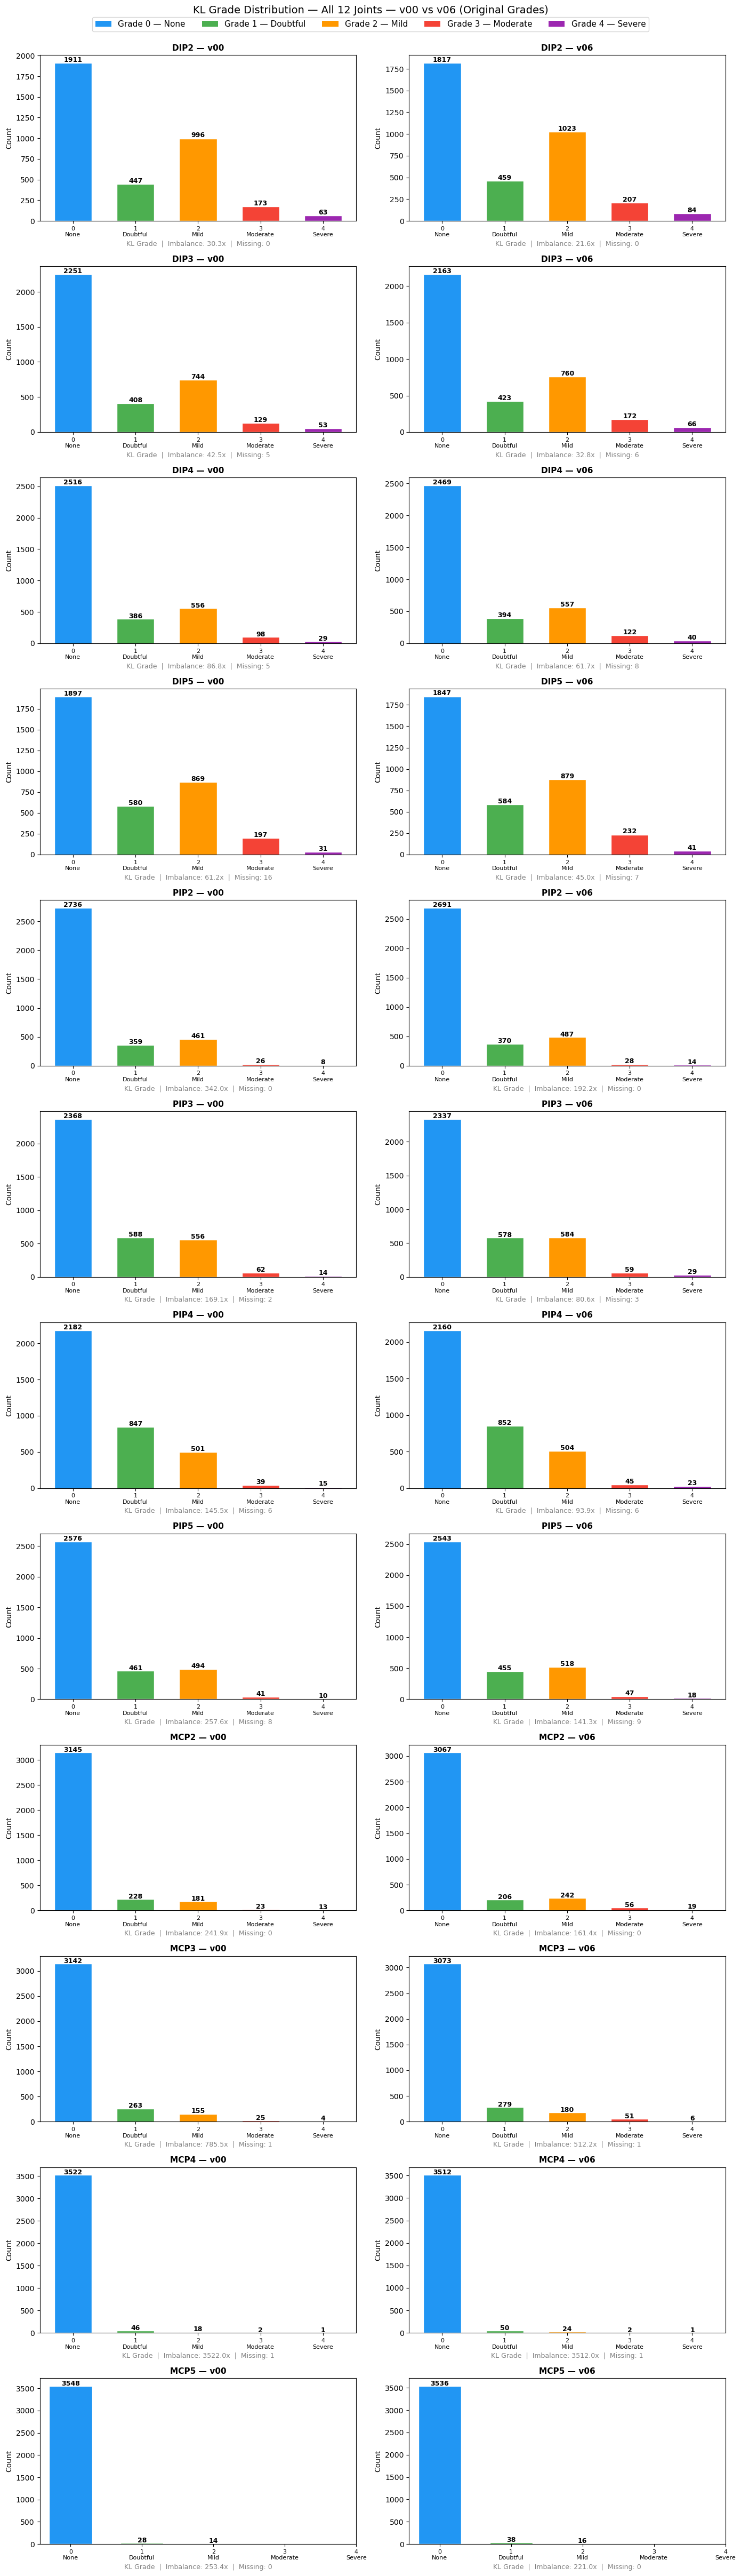

Chart saved to reports folder.


In [20]:
# Visualize all 12 joints — v00 vs v06 side by side — ORIGINAL grades no merging
import matplotlib.pyplot as plt

ALL_JOINTS = ['DIP2', 'DIP3', 'DIP4', 'DIP5',
              'PIP2', 'PIP3', 'PIP4', 'PIP5',
              'MCP2', 'MCP3', 'MCP4', 'MCP5']

fig, axes = plt.subplots(12, 2, figsize=(14, 48))

for i, joint in enumerate(ALL_JOINTS):
    for j, visit in enumerate(['v00', 'v06']):
        ax = axes[i][j]
        col = f'{visit}{joint}_KL'

        # Use original data — no merging
        counts = df[col].value_counts().sort_index().dropna()
        grades_present = counts.index.astype(int).tolist()

        # Color map — one color per grade
        color_map = {
            0: '#2196F3',  # blue
            1: '#4CAF50',  # green
            2: '#FF9800',  # orange
            3: '#F44336',  # red
            4: '#9C27B0',  # purple
        }
        colors = [color_map.get(g, '#AAAAAA') for g in grades_present]

        ax.bar(grades_present, counts.values,
               color=colors, edgecolor='white', width=0.6)

        # Always show all 5 original grade ticks for consistency
        ax.set_xticks([0, 1, 2, 3, 4])
        ax.set_xticklabels(['0\nNone', '1\nDoubtful', '2\nMild',
                            '3\nModerate', '4\nSevere'], fontsize=8)

        # Title
        ax.set_title(f'{joint} — {visit}', fontsize=11, fontweight='bold')

        # Imbalance ratio and missing values in xlabel
        ratio = counts.max() / counts.min() if counts.min() > 0 else float('inf')
        missing = df[col].isnull().sum()
        ax.set_xlabel(
            f'KL Grade  |  Imbalance: {ratio:.1f}x  |  Missing: {missing}',
            fontsize=9, color='gray'
        )
        ax.set_ylabel('Count')

        # Count labels on bars
        for grade, count in zip(grades_present, counts.values):
            ax.text(grade, count + 15, str(int(count)),
                    ha='center', fontsize=9, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2196F3', label='Grade 0 — None'),
    Patch(facecolor='#4CAF50', label='Grade 1 — Doubtful'),
    Patch(facecolor='#FF9800', label='Grade 2 — Mild'),
    Patch(facecolor='#F44336', label='Grade 3 — Moderate'),
    Patch(facecolor='#9C27B0', label='Grade 4 — Severe'),
]
fig.legend(handles=legend_elements, loc='upper center',
           ncol=5, fontsize=11, bbox_to_anchor=(0.5, 1.002),
           frameon=True)

plt.suptitle('KL Grade Distribution — All 12 Joints — v00 vs v06 (Original Grades)',
             fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'all_joints_v00_vs_v06_original.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports folder.")

In [6]:
# Look at just the KL columns for visit 0
kl_cols_v00 = [col for col in df.columns if col.startswith('v00') and col.endswith('_KL')]
print("Visit 0 KL columns:")
print(kl_cols_v00)
print(f"\nTotal KL joints at visit 0: {len(kl_cols_v00)}")

# Summary statistics for all KL scores
print("\nKL score summary across all joints:")
print(df[kl_cols_v00].describe())

Visit 0 KL columns:
['v00DIP2_KL', 'v00DIP3_KL', 'v00DIP4_KL', 'v00DIP5_KL', 'v00IP1_KL', 'v00PIP2_KL', 'v00PIP3_KL', 'v00PIP4_KL', 'v00PIP5_KL', 'v00MCP1_KL', 'v00MCP2_KL', 'v00MCP3_KL', 'v00MCP4_KL', 'v00MCP5_KL', 'v00CMC1_KL', 'v00STT_KL', 'v00KLReview_KL', 'v00MEReview_KL', 'v00FlagOther_KL']

Total KL joints at visit 0: 19

KL score summary across all joints:
        v00DIP2_KL   v00DIP3_KL   v00DIP4_KL   v00DIP5_KL    v00IP1_KL  \
count  3590.000000  3585.000000  3585.000000  3574.000000  3589.000000   
mean      0.894150     0.695955     0.532218     0.848629     0.729451   
std       1.072176     1.010076     0.905793     1.024621     0.981191   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.000000     0.000000     0.000000     0.000000     0.000000   
50%       0.000000     0.000000     0.000000     0.000000     0.000000   
75%       2.000000     2.000000     1.000000     2.000000     2.000000   
max       4.000000     4.000000     4.000

In [7]:
# Check how many unique KL grade values exist
print("Unique KL grade values across all joints:")
all_kl_values = df[kl_cols_v00].stack().dropna().unique()
print(sorted(all_kl_values))

# Check missing values per joint
print("\nMissing KL scores per joint:")
print(df[kl_cols_v00].isnull().sum())

Unique KL grade values across all joints:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]

Missing KL scores per joint:
v00DIP2_KL            0
v00DIP3_KL            5
v00DIP4_KL            5
v00DIP5_KL           16
v00IP1_KL             1
v00PIP2_KL            0
v00PIP3_KL            2
v00PIP4_KL            6
v00PIP5_KL            8
v00MCP1_KL            2
v00MCP2_KL            0
v00MCP3_KL            1
v00MCP4_KL            1
v00MCP5_KL            0
v00CMC1_KL           16
v00STT_KL            19
v00KLReview_KL        0
v00MEReview_KL        0
v00FlagOther_KL    3584
dtype: int64


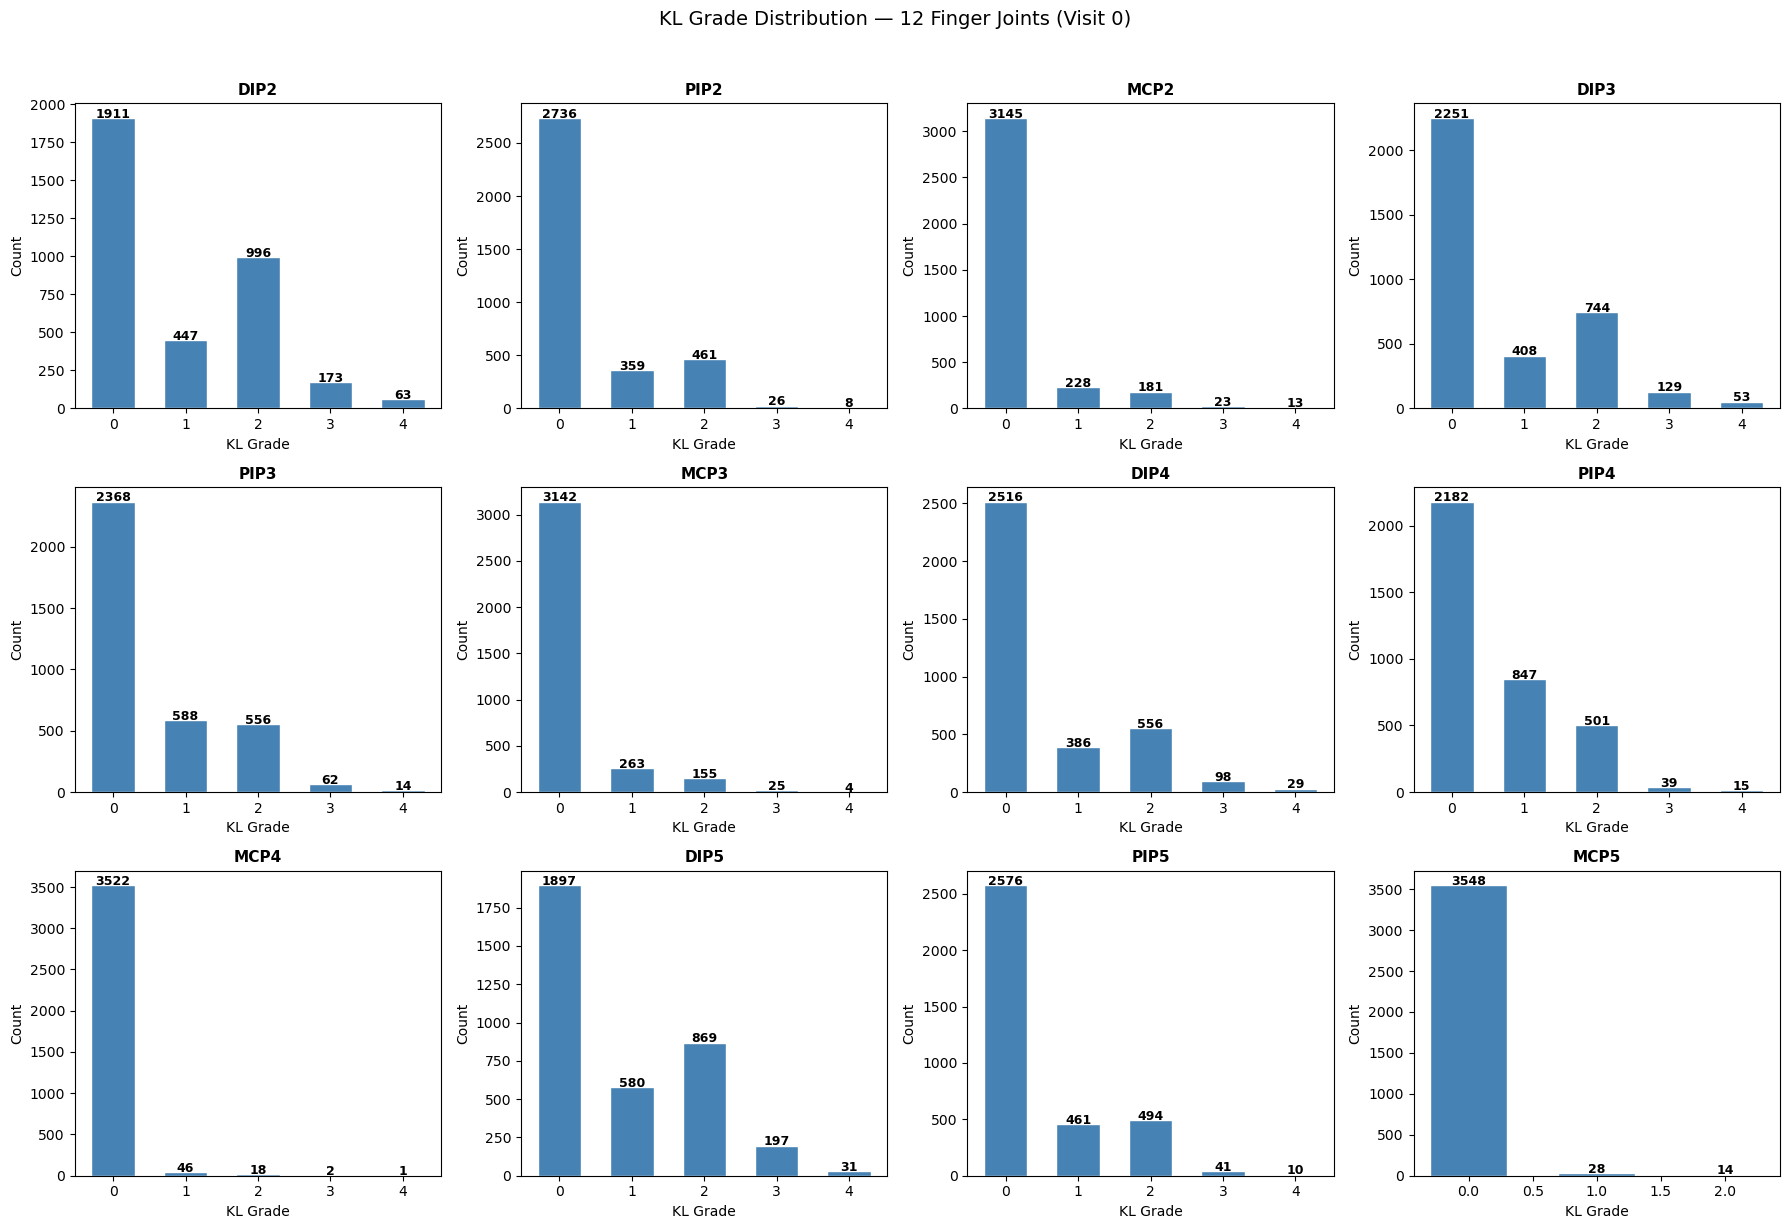

In [8]:
#confirm the KL distribution across all 12 joints
#12 KL columns at visit 0 
KL_COLS = [
    'v00DIP2_KL', 'v00PIP2_KL', 'v00MCP2_KL',
    'v00DIP3_KL', 'v00PIP3_KL', 'v00MCP3_KL',
    'v00DIP4_KL', 'v00PIP4_KL', 'v00MCP4_KL',
    'v00DIP5_KL', 'v00PIP5_KL', 'v00MCP5_KL',
]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(KL_COLS):
    counts = df[col].value_counts().sort_index().dropna()
    axes[i].bar(counts.index.astype(int), counts.values,
                color='steelblue', edgecolor='white', width=0.6)
    axes[i].set_title(col.replace('v00', '').replace('_KL', ''), 
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('KL Grade')
    axes[i].set_ylabel('Count')
    for grade, count in counts.items():
        axes[i].text(grade, count + 2, str(count), 
                     ha='center', fontsize=9, fontweight='bold')

plt.suptitle('KL Grade Distribution — 12 Finger Joints (Visit 0)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'twelve_joint_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Summary statistics for all 12 joints
print("=== KL Grade Summary — 12 Joints ===\n")
for col in KL_COLS:
    counts = df[col].value_counts().sort_index()
    missing = df[col].isnull().sum()
    total = df[col].count()
    imbalance = counts.max() / counts.min() if counts.min() > 0 else float('inf')
    print(f"{col.replace('v00','').replace('_KL',''):10} | "
          f"Total: {total} | Missing: {missing} | "
          f"Imbalance ratio: {imbalance:.1f}x")
    print(f"{'':10}   Grades: {counts.to_dict()}")
    print()

=== KL Grade Summary — 12 Joints ===

DIP2       | Total: 3590 | Missing: 0 | Imbalance ratio: 30.3x
             Grades: {0: 1911, 1: 447, 2: 996, 3: 173, 4: 63}

PIP2       | Total: 3590 | Missing: 0 | Imbalance ratio: 342.0x
             Grades: {0: 2736, 1: 359, 2: 461, 3: 26, 4: 8}

MCP2       | Total: 3590 | Missing: 0 | Imbalance ratio: 241.9x
             Grades: {0: 3145, 1: 228, 2: 181, 3: 23, 4: 13}

DIP3       | Total: 3585 | Missing: 5 | Imbalance ratio: 42.5x
             Grades: {0.0: 2251, 1.0: 408, 2.0: 744, 3.0: 129, 4.0: 53}

PIP3       | Total: 3588 | Missing: 2 | Imbalance ratio: 169.1x
             Grades: {0.0: 2368, 1.0: 588, 2.0: 556, 3.0: 62, 4.0: 14}

MCP3       | Total: 3589 | Missing: 1 | Imbalance ratio: 785.5x
             Grades: {0.0: 3142, 1.0: 263, 2.0: 155, 3.0: 25, 4.0: 4}

DIP4       | Total: 3585 | Missing: 5 | Imbalance ratio: 86.8x
             Grades: {0.0: 2516, 1.0: 386, 2.0: 556, 3.0: 98, 4.0: 29}

PIP4       | Total: 3584 | Missing: 6 | Imb

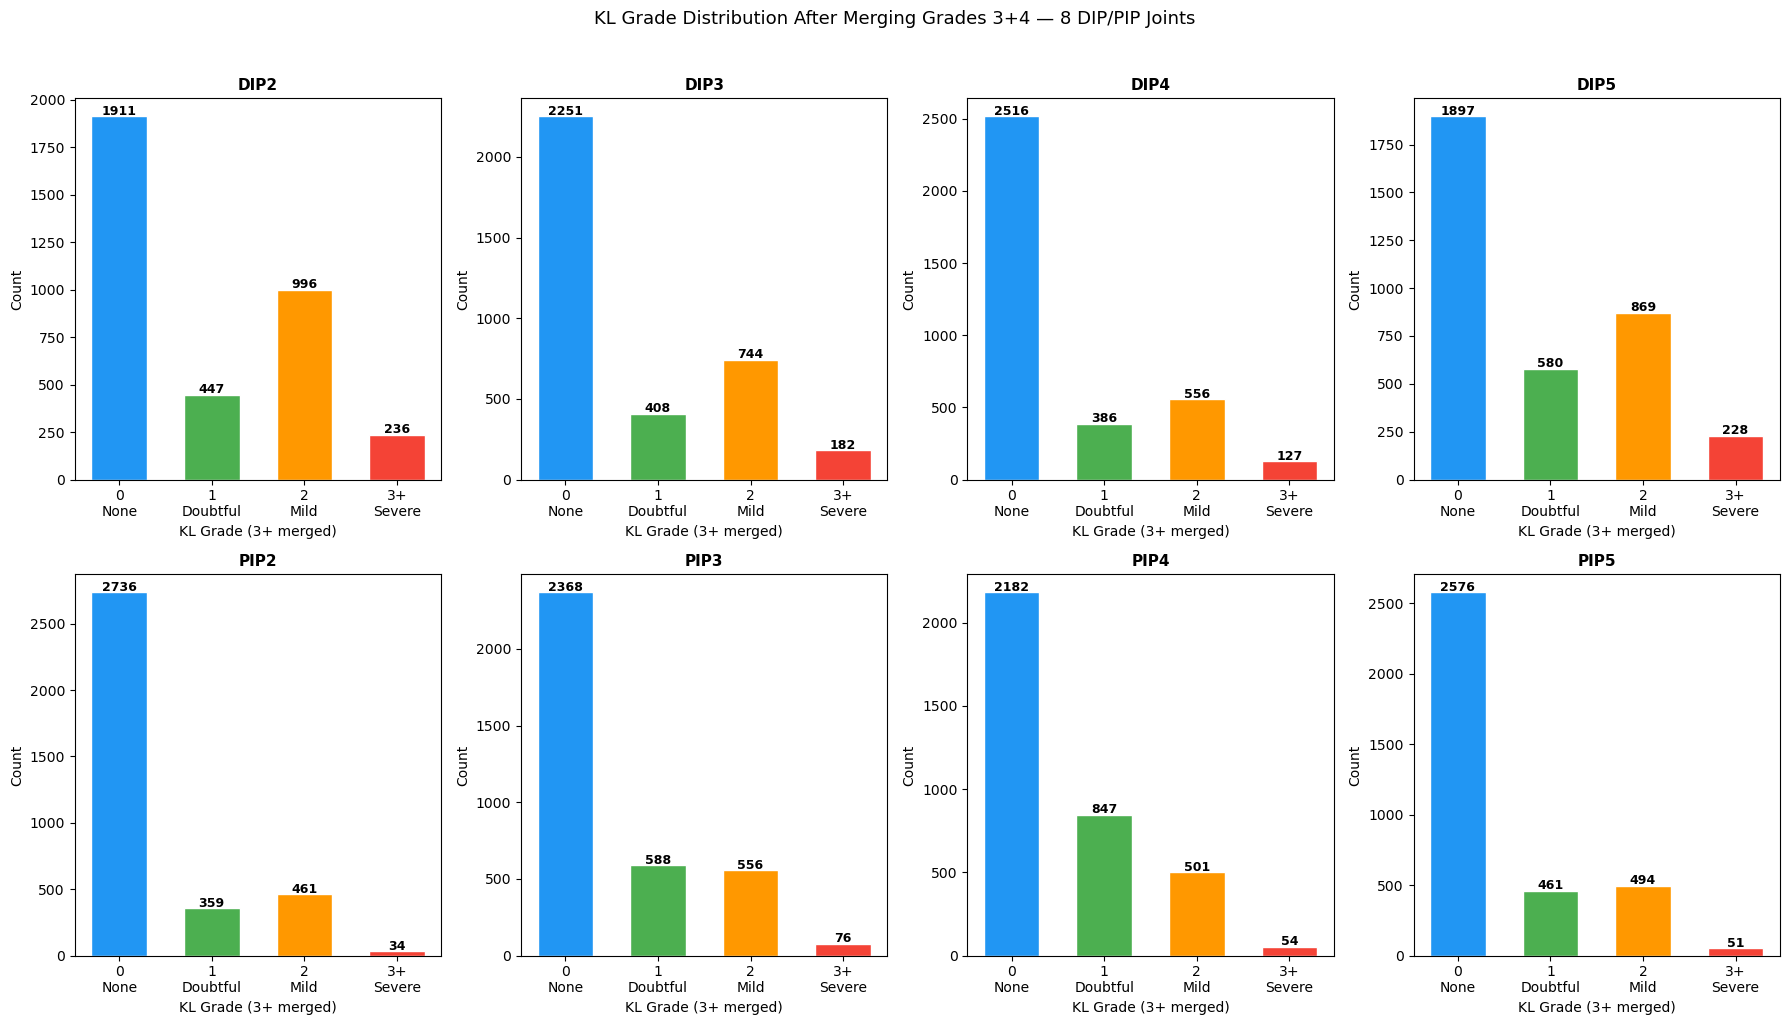

In [10]:
#impact of merging grade 3 and 4 
# Compare original vs merged grade distributions
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

KEEP_COLS = [
    'v00DIP2_KL', 'v00DIP3_KL', 'v00DIP4_KL', 'v00DIP5_KL',
    'v00PIP2_KL', 'v00PIP3_KL', 'v00PIP4_KL', 'v00PIP5_KL',
]

for i, col in enumerate(KEEP_COLS):
    ax = axes[i // 4][i % 4]
    
    # Merge grade 3 and 4 into grade 3
    merged = df[col].copy()
    merged = merged.replace(4.0, 3.0).replace(4, 3)
    
    counts = merged.value_counts().sort_index().dropna()
    bars = ax.bar(counts.index.astype(int), counts.values,
                  color=['#2196F3','#4CAF50','#FF9800','#F44336'],
                  edgecolor='white', width=0.6)
    
    joint_name = col.replace('v00','').replace('_KL','')
    ax.set_title(joint_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('KL Grade (3+ merged)')
    ax.set_ylabel('Count')
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['0\nNone', '1\nDoubtful', '2\nMild', '3+\nSevere'])
    
    for grade, count in counts.items():
        ax.text(int(grade), count + 10, str(count),
                ha='center', fontsize=9, fontweight='bold')

plt.suptitle('KL Grade Distribution After Merging Grades 3+4 — 8 DIP/PIP Joints',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'merged_grade_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()

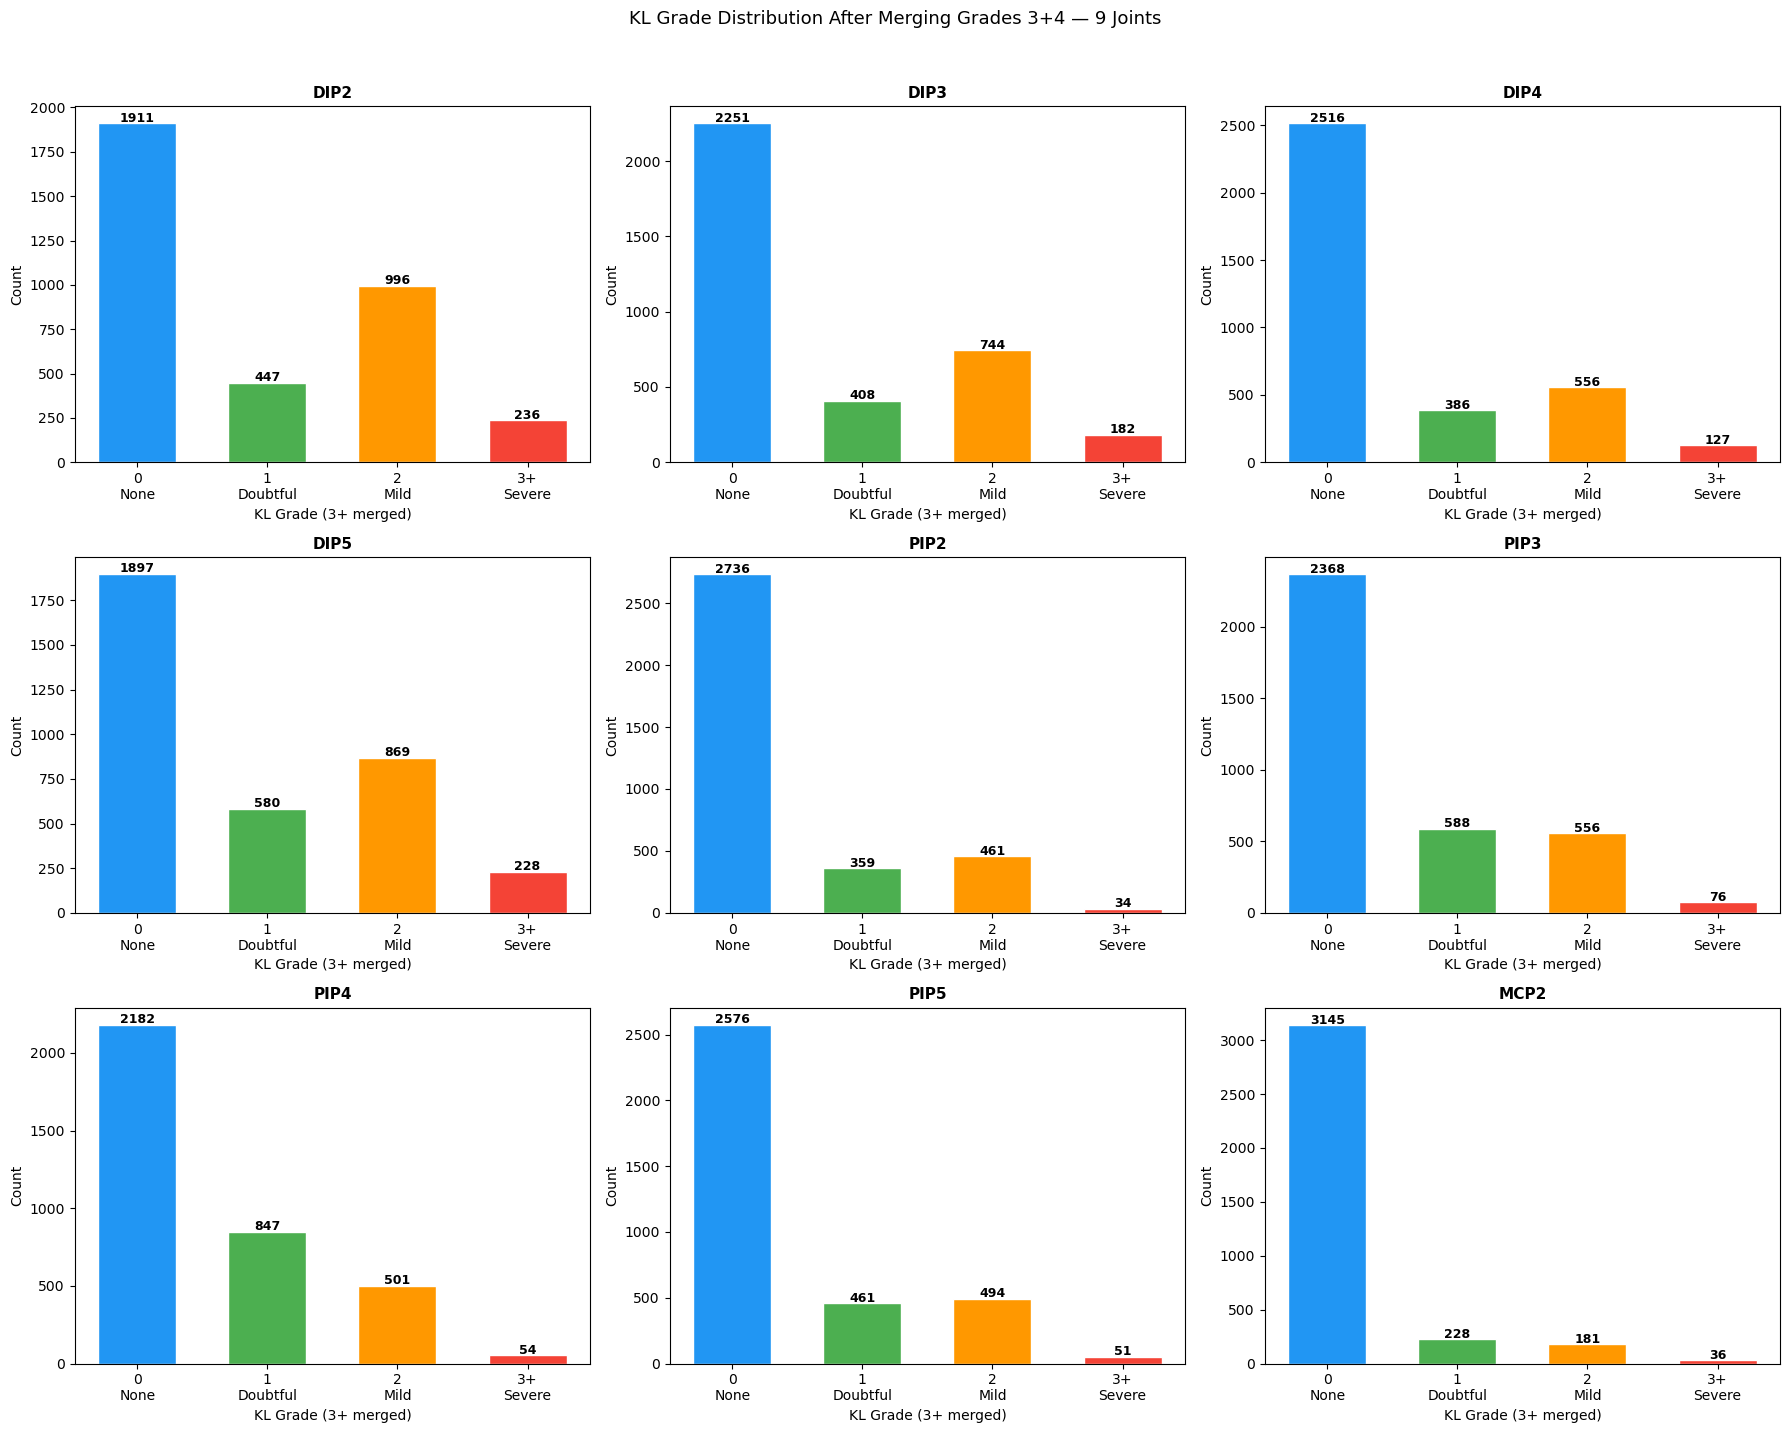

In [19]:
# Compare original vs merged grade distributions mcp2 joint included 
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

KEEP_COLS = [
    'v00DIP2_KL', 'v00DIP3_KL', 'v00DIP4_KL', 'v00DIP5_KL',
    'v00PIP2_KL', 'v00PIP3_KL', 'v00PIP4_KL', 'v00PIP5_KL',
    'v00MCP2_KL',  # added
]

for i, col in enumerate(KEEP_COLS):
    ax = axes[i // 3][i % 3]  # changed from 4 to 3
    
    # Merge grade 3 and 4 into grade 3
    merged = df[col].copy()
    merged = merged.replace(4.0, 3.0).replace(4, 3)
    
    counts = merged.value_counts().sort_index().dropna()
    bars = ax.bar(counts.index.astype(int), counts.values,
                  color=['#2196F3','#4CAF50','#FF9800','#F44336'],
                  edgecolor='white', width=0.6)
    
    joint_name = col.replace('v00','').replace('_KL','')
    ax.set_title(joint_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('KL Grade (3+ merged)')
    ax.set_ylabel('Count')
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['0\nNone', '1\nDoubtful', '2\nMild', '3+\nSevere'])
    
    for grade, count in counts.items():
        ax.text(int(grade), count + 10, str(count),
                ha='center', fontsize=9, fontweight='bold')

plt.suptitle('KL Grade Distribution After Merging Grades 3+4 — 9 Joints',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'merged_grade_distributions.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Final summary after merging
print("=== Final Grade Counts After Merging Grade 3+4 ===\n")
for col in KEEP_COLS:
    merged = df[col].copy().replace(4.0, 3.0).replace(4, 3)
    counts = merged.value_counts().sort_index().dropna()
    imbalance = counts.max() / counts.min()
    joint_name = col.replace('v00','').replace('_KL','')
    print(f"{joint_name:8} | Grades: {counts.to_dict()} | "
          f"New imbalance ratio: {imbalance:.1f}x")

=== Final Grade Counts After Merging Grade 3+4 ===

DIP2     | Grades: {0: 1911, 1: 447, 2: 996, 3: 236} | New imbalance ratio: 8.1x
DIP3     | Grades: {0.0: 2251, 1.0: 408, 2.0: 744, 3.0: 182} | New imbalance ratio: 12.4x
DIP4     | Grades: {0.0: 2516, 1.0: 386, 2.0: 556, 3.0: 127} | New imbalance ratio: 19.8x
DIP5     | Grades: {0.0: 1897, 1.0: 580, 2.0: 869, 3.0: 228} | New imbalance ratio: 8.3x
PIP2     | Grades: {0: 2736, 1: 359, 2: 461, 3: 34} | New imbalance ratio: 80.5x
PIP3     | Grades: {0.0: 2368, 1.0: 588, 2.0: 556, 3.0: 76} | New imbalance ratio: 31.2x
PIP4     | Grades: {0.0: 2182, 1.0: 847, 2.0: 501, 3.0: 54} | New imbalance ratio: 40.4x
PIP5     | Grades: {0.0: 2576, 1.0: 461, 2.0: 494, 3.0: 51} | New imbalance ratio: 50.5x


In [12]:
# compare v00 and v06 imbalance side by side 
# Define both visit columns for the 8 joints
JOINTS = ['DIP2', 'DIP3', 'DIP4', 'DIP5', 'PIP2', 'PIP3', 'PIP4', 'PIP5']

v00_cols = [f'v00{j}_KL' for j in JOINTS]
v06_cols = [f'v06{j}_KL' for j in JOINTS]

print("=== Imbalance Ratio Comparison: v00 vs v06 ===\n")
print(f"{'Joint':<8} | {'v00 Ratio':>10} | {'v06 Ratio':>10} | {'Better':>8}")
print("-" * 45)

for joint, c00, c06 in zip(JOINTS, v00_cols, v06_cols):
    # v00 imbalance
    counts00 = df[c00].replace(4.0, 3.0).replace(4, 3).value_counts()
    ratio00 = counts00.max() / counts00.min() if counts00.min() > 0 else float('inf')
    
    # v06 imbalance
    counts06 = df[c06].replace(4.0, 3.0).replace(4, 3).value_counts()
    ratio06 = counts06.max() / counts06.min() if counts06.min() > 0 else float('inf')
    
    better = "v06" if ratio06 < ratio00 else "v00"
    print(f"{joint:<8} | {ratio00:>10.1f} | {ratio06:>10.1f} | {better:>8}")
    


=== Imbalance Ratio Comparison: v00 vs v06 ===

Joint    |  v00 Ratio |  v06 Ratio |   Better
---------------------------------------------
DIP2     |        8.1 |        6.2 |      v06
DIP3     |       12.4 |        9.1 |      v06
DIP4     |       19.8 |       15.2 |      v06
DIP5     |        8.3 |        6.8 |      v06
PIP2     |       80.5 |       64.1 |      v06
PIP3     |       31.2 |       26.6 |      v06
PIP4     |       40.4 |       31.8 |      v06
PIP5     |       50.5 |       39.1 |      v06


In [14]:
# Check MCP joints for both visits
MCP_JOINTS = ['MCP2', 'MCP3', 'MCP4', 'MCP5']

mcp_v00_cols = [f'v00{j}_KL' for j in MCP_JOINTS]
mcp_v06_cols = [f'v06{j}_KL' for j in MCP_JOINTS]

print("=== MCP Joints: v00 vs v06 Imbalance + Grade Distribution ===\n")

for joint, c00, c06 in zip(MCP_JOINTS, mcp_v00_cols, mcp_v06_cols):
    print(f"{'='*50}")
    print(f"  {joint}")
    print(f"{'='*50}")
    
    for col, visit in [(c00, 'v00'), (c06, 'v06')]:
        merged = df[col].copy().replace(4.0, 3.0).replace(4, 3)
        counts = merged.value_counts().sort_index().dropna()
        ratio = counts.max() / counts.min() if counts.min() > 0 else float('inf')
        missing = df[col].isnull().sum()
        grades_present = sorted(counts.index.astype(int).tolist())
        
        print(f"\n  {visit}:")
        print(f"  Grades present : {grades_present}")
        print(f"  Counts         : {counts.to_dict()}")
        print(f"  Missing        : {missing}")
        print(f"  Imbalance ratio: {ratio:.1f}x")
    print()

=== MCP Joints: v00 vs v06 Imbalance + Grade Distribution ===

  MCP2

  v00:
  Grades present : [0, 1, 2, 3]
  Counts         : {0: 3145, 1: 228, 2: 181, 3: 36}
  Missing        : 0
  Imbalance ratio: 87.4x

  v06:
  Grades present : [0, 1, 2, 3]
  Counts         : {0: 3067, 1: 206, 2: 242, 3: 75}
  Missing        : 0
  Imbalance ratio: 40.9x

  MCP3

  v00:
  Grades present : [0, 1, 2, 3]
  Counts         : {0.0: 3142, 1.0: 263, 2.0: 155, 3.0: 29}
  Missing        : 1
  Imbalance ratio: 108.3x

  v06:
  Grades present : [0, 1, 2, 3]
  Counts         : {0.0: 3073, 1.0: 279, 2.0: 180, 3.0: 57}
  Missing        : 1
  Imbalance ratio: 53.9x

  MCP4

  v00:
  Grades present : [0, 1, 2, 3]
  Counts         : {0.0: 3522, 1.0: 46, 2.0: 18, 3.0: 3}
  Missing        : 1
  Imbalance ratio: 1174.0x

  v06:
  Grades present : [0, 1, 2, 3]
  Counts         : {0.0: 3512, 1.0: 50, 2.0: 24, 3.0: 3}
  Missing        : 1
  Imbalance ratio: 1170.7x

  MCP5

  v00:
  Grades present : [0, 1, 2]
  Counts  

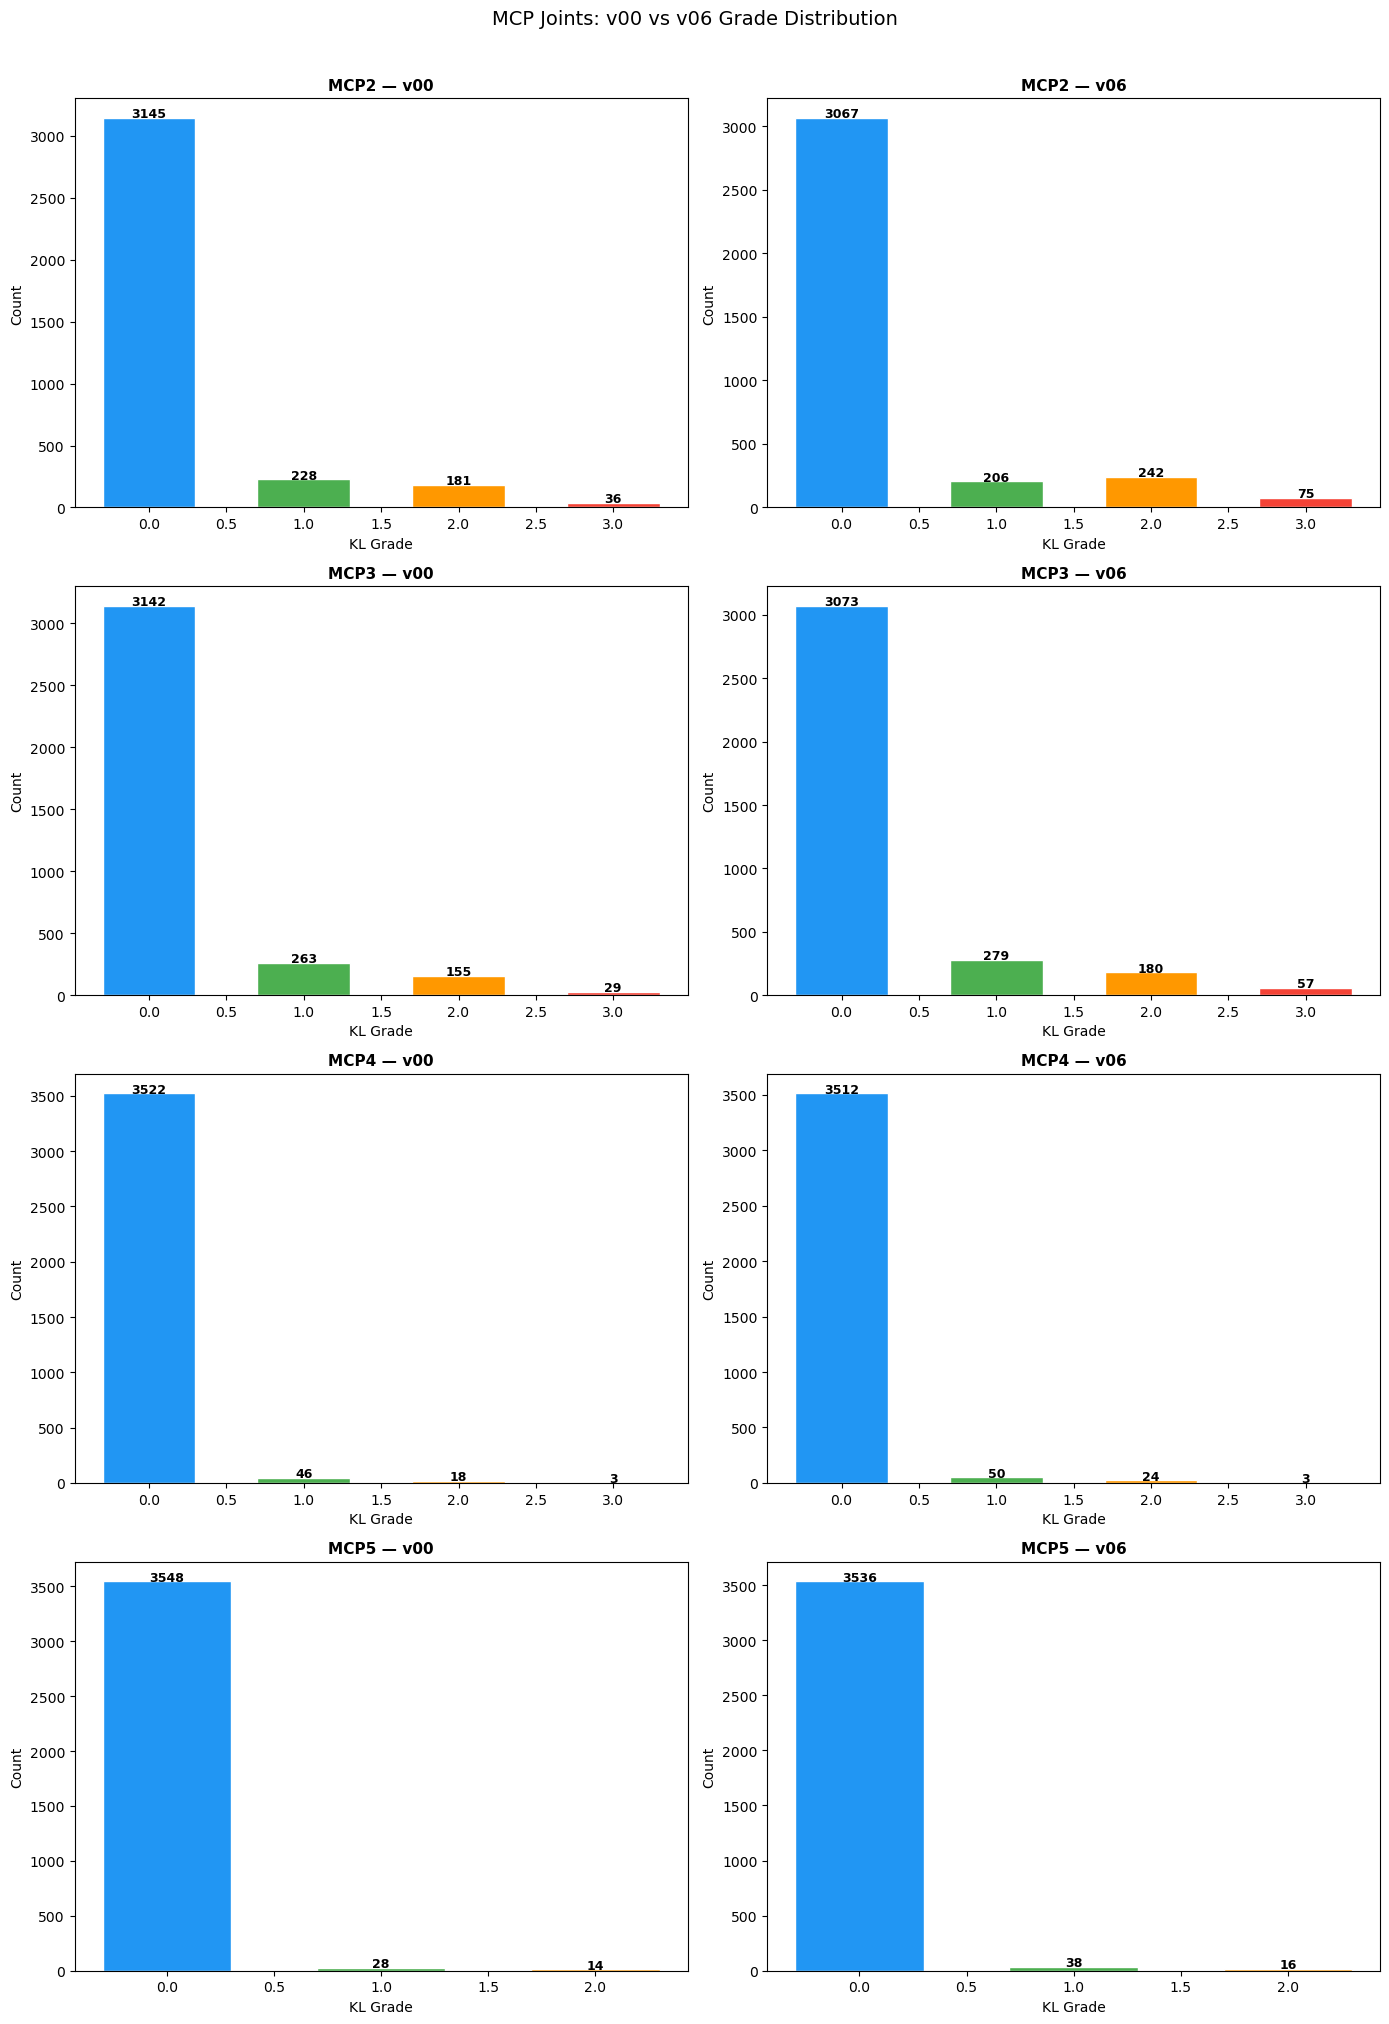

In [15]:
# Visual comparison for MCP joints
fig, axes = plt.subplots(4, 2, figsize=(14, 20))

for i, (joint, c00, c06) in enumerate(zip(MCP_JOINTS, mcp_v00_cols, mcp_v06_cols)):
    for j, (col, visit) in enumerate([(c00, 'v00'), (c06, 'v06')]):
        ax = axes[i][j]
        merged = df[col].copy().replace(4.0, 3.0).replace(4, 3)
        counts = merged.value_counts().sort_index().dropna()
        
        colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
        ax.bar(counts.index.astype(int), counts.values,
               color=colors[:len(counts)], edgecolor='white', width=0.6)
        ax.set_title(f'{joint} — {visit}', fontsize=11, fontweight='bold')
        ax.set_xlabel('KL Grade')
        ax.set_ylabel('Count')
        for grade, count in counts.items():
            ax.text(int(grade), count + 5, str(count),
                    ha='center', fontsize=9, fontweight='bold')

plt.suptitle('MCP Joints: v00 vs v06 Grade Distribution',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'mcp_v00_vs_v06.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Final confirmed joint list
FINAL_JOINTS = [
    # DIP joints — best balance, keep all
    'DIP2', 'DIP3', 'DIP4', 'DIP5',
    
    # PIP joints — borderline but manageable, keep all
    'PIP2', 'PIP3', 'PIP4', 'PIP5',
    
    # MCP joints — only MCP2 makes the cut
    'MCP2',
]

# That gives you 9 joints total
print(f"Total joints selected: {len(FINAL_JOINTS)}")

Total joints selected: 9


In [17]:
ALL_JOINTS = ['DIP2','DIP3','DIP4','DIP5',
              'PIP2','PIP3','PIP4','PIP5',
              'MCP2','MCP3','MCP4','MCP5']

print(f"{'Joint':<8} | {'Imbalance':>10} | {'Grade 3 Count':>14} | {'Decision':>10}")
print("-" * 52)

decisions = {
    'DIP2': 'KEEP',  'DIP3': 'KEEP',
    'DIP4': 'KEEP',  'DIP5': 'KEEP',
    'PIP2': 'KEEP',  'PIP3': 'KEEP',
    'PIP4': 'KEEP',  'PIP5': 'KEEP',
    'MCP2': 'KEEP',  'MCP3': 'DROP',
    'MCP4': 'DROP',  'MCP5': 'DROP',
}

for joint in ALL_JOINTS:
    col = f'v06{joint}_KL'
    merged = df[col].copy().replace(4.0, 3.0).replace(4, 3)
    counts = merged.value_counts().sort_index().dropna()
    ratio = counts.max() / counts.min() if counts.min() > 0 else float('inf')
    g3 = int(counts.get(3.0, counts.get(3, 0)))
    decision = decisions[joint]
    marker = '✓' if decision == 'KEEP' else '✗'
    print(f"{joint:<8} | {ratio:>9.1f}x | {g3:>14} | {marker} {decision}")

Joint    |  Imbalance |  Grade 3 Count |   Decision
----------------------------------------------------
DIP2     |       6.2x |            291 | ✓ KEEP
DIP3     |       9.1x |            238 | ✓ KEEP
DIP4     |      15.2x |            162 | ✓ KEEP
DIP5     |       6.8x |            273 | ✓ KEEP
PIP2     |      64.1x |             42 | ✓ KEEP
PIP3     |      26.6x |             88 | ✓ KEEP
PIP4     |      31.8x |             68 | ✓ KEEP
PIP5     |      39.1x |             65 | ✓ KEEP
MCP2     |      40.9x |             75 | ✓ KEEP
MCP3     |      53.9x |             57 | ✗ DROP
MCP4     |    1170.7x |              3 | ✗ DROP
MCP5     |     221.0x |              0 | ✗ DROP


In [37]:
# Check distribution after merging grades 3 and 4
valid_df['kl_grade_merged'] = valid_df['kl_grade'].replace({4: 3})

print("── Final grade distribution after merging 3+4 ────")
counts = valid_df['kl_grade_merged'].value_counts().sort_index()
total  = len(valid_df)

for grade, count in counts.items():
    pct = count / total * 100
    bar = '█' * int(pct / 2)
    print(f"Grade {grade} : {count:>6} ({pct:>5.1f}%)  {bar}")

print(f"\nTotal samples  : {total}")
print(f"Imbalance ratio: {counts.max() / counts.min():.1f}x")

── Final grade distribution after merging 3+4 ────
Grade 0 :  21392 ( 70.2%)  ███████████████████████████████████
Grade 1 :   4210 ( 13.8%)  ██████
Grade 2 :   4346 ( 14.3%)  ███████
Grade 3 :    524 (  1.7%)  

Total samples  : 30472
Imbalance ratio: 40.8x


In [38]:
#per joint breakdown to see if any individual joint is worse than 40.8x overall
print("── Merged grade distribution per joint ───────────")
print(f"\n{'Joint':<8} | {'Grade 0':>8} | {'Grade 1':>8} | "
      f"{'Grade 2':>8} | {'Grade 3+':>8} | {'Imbalance':>10}")
print("-" * 60)

for joint in FINAL_JOINTS:
    joint_df = valid_df[valid_df['joint'] == joint]
    counts   = joint_df['kl_grade_merged'].value_counts().sort_index()
    g0 = counts.get(0, 0)
    g1 = counts.get(1, 0)
    g2 = counts.get(2, 0)
    g3 = counts.get(3, 0)
    ratio = counts.max() / counts.min() if counts.min() > 0 else float('inf')
    print(f"{joint.upper():<8} | {g0:>8} | {g1:>8} | "
          f"{g2:>8} | {g3:>8} | {ratio:>9.1f}x")

── Merged grade distribution per joint ───────────

Joint    |  Grade 0 |  Grade 1 |  Grade 2 | Grade 3+ |  Imbalance
------------------------------------------------------------
DIP2     |     1891 |      434 |      793 |      120 |      15.8x
DIP3     |     2232 |      393 |      592 |      100 |      22.3x
DIP4     |     2497 |      376 |      461 |       61 |      40.9x
DIP5     |     1874 |      571 |      700 |      105 |      17.8x
PIP2     |     2713 |      352 |      373 |       19 |     142.8x
PIP3     |     2345 |      576 |      474 |       37 |      63.4x
PIP4     |     2165 |      840 |      410 |       34 |      63.7x
PIP5     |     2559 |      451 |      408 |       24 |     106.6x
MCP2     |     3116 |      217 |      135 |       24 |     129.8x


In [39]:
# Grade 3+ sample threshold analysis
print("── Grade 3+ sample count analysis ───────────────")
print(f"\n{'Joint':<8} | {'Grade 3+':>8} | {'Usability':>12}")
print("-" * 35)

thresholds = {
    'DIP2' : 120, 'DIP3': 100, 'DIP4':  61, 'DIP5': 105,
    'PIP2' :  19, 'PIP3':  37, 'PIP4':  34, 'PIP5':  24,
    'MCP2' :  24
}

for joint, g3_count in thresholds.items():
    if g3_count >= 80:
        usability = 'Strong'
    elif g3_count >= 40:
        usability = 'Acceptable'
    elif g3_count >= 20:
        usability = 'Borderline'
    else:
        usability = 'Weak'
    print(f"{joint:<8} | {g3_count:>8} | {usability:>12}")

── Grade 3+ sample count analysis ───────────────

Joint    | Grade 3+ |    Usability
-----------------------------------
DIP2     |      120 |       Strong
DIP3     |      100 |       Strong
DIP4     |       61 |   Acceptable
DIP5     |      105 |       Strong
PIP2     |       19 |         Weak
PIP3     |       37 |   Borderline
PIP4     |       34 |   Borderline
PIP5     |       24 |   Borderline
MCP2     |       24 |   Borderline


In [40]:
# Final confirmed joint selection — PIP2 dropped
FINAL_JOINTS = [
    'dip2',   # Strong  — 120 grade 3+ samples
    'dip3',   # Strong  — 100 grade 3+ samples
    'dip4',   # Accept  —  61 grade 3+ samples
    'dip5',   # Strong  — 105 grade 3+ samples
    'pip3',   # Border  —  37 grade 3+ samples
    'pip4',   # Border  —  34 grade 3+ samples
    'pip5',   # Border  —  24 grade 3+ samples
    'mcp2',   # Border  —  24 grade 3+ samples
]

KL_COLS_MAP = {
    'dip2': 'v00DIP2_KL', 'dip3': 'v00DIP3_KL',
    'dip4': 'v00DIP4_KL', 'dip5': 'v00DIP5_KL',
    'pip3': 'v00PIP3_KL', 'pip4': 'v00PIP4_KL',
    'pip5': 'v00PIP5_KL', 'mcp2': 'v00MCP2_KL',
}

print(f"Final joint count : {len(FINAL_JOINTS)}")
print(f"Joints selected   : {[j.upper() for j in FINAL_JOINTS]}")

Final joint count : 8
Joints selected   : ['DIP2', 'DIP3', 'DIP4', 'DIP5', 'PIP3', 'PIP4', 'PIP5', 'MCP2']


In [42]:
valid_samples = []

for _, row in df.iterrows():
    patient_id = str(int(row['id']))
    
    if patient_id not in patients_with_images:
        continue
    
    for joint in FINAL_JOINTS:
        kl_col   = KL_COLS_MAP[joint]
        kl_grade = row[kl_col]
        img_path = os.path.join(IMAGE_DIR, f'{patient_id}_{joint}.png')
        
        if os.path.exists(img_path) and not pd.isna(kl_grade):
            valid_samples.append({
                'patient_id'      : patient_id,
                'joint'           : joint,
                'kl_grade'        : int(kl_grade),
                'kl_grade_merged' : int(min(kl_grade, 3)),
                'image_path'      : img_path
            })

valid_df = pd.DataFrame(valid_samples)

# Summary
counts = valid_df['kl_grade_merged'].value_counts().sort_index()
total  = len(valid_df)

print(f"── Final dataset summary ──────────────────────────")
print(f"Total samples     : {total}")
print(f"Joints            : {len(FINAL_JOINTS)}")
print(f"Imbalance ratio   : {counts.max() / counts.min():.1f}x")
print(f"\nGrade distribution:")
for grade, count in counts.items():
    pct = count / total * 100
    bar = '█' * int(pct / 2)
    print(f"  Grade {grade} : {count:>6} ({pct:>5.1f}%)  {bar}")

── Final dataset summary ──────────────────────────
Total samples     : 27015
Joints            : 8
Imbalance ratio   : 37.0x

Grade distribution:
  Grade 0 :  18679 ( 69.1%)  ██████████████████████████████████
  Grade 1 :   3858 ( 14.3%)  ███████
  Grade 2 :   3973 ( 14.7%)  ███████
  Grade 3 :    505 (  1.9%)  


In [43]:
#create master_dataset for training model
splits_dir = os.path.join(BASE_DIR, 'data', 'splits')
os.makedirs(splits_dir, exist_ok=True)

save_path = os.path.join(splits_dir, 'master_dataset.csv')
valid_df.to_csv(save_path, index=False)

print(f"Main dataset saved to : {save_path}")
print(f"Shape                   : {valid_df.shape}")
print(f"Columns                 : {valid_df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(valid_df.head())

Master dataset saved to : C:\Users\snime\OneDrive\Documents\my transciripts\Boston-University\Spring 2026\CS790 A1 Computer Vision in AI\final project\OA-severity-classification\data\splits\master_dataset.csv
Shape                   : (27015, 5)
Columns                 : ['patient_id', 'joint', 'kl_grade', 'kl_grade_merged', 'image_path']

First 5 rows:
  patient_id joint  kl_grade  kl_grade_merged  \
0    9000099  dip2         0                0   
1    9000099  dip3         1                1   
2    9000099  dip4         1                1   
3    9000099  dip5         1                1   
4    9000099  pip3         0                0   

                                          image_path  
0  C:\Users\snime\OneDrive\Documents\my transciri...  
1  C:\Users\snime\OneDrive\Documents\my transciri...  
2  C:\Users\snime\OneDrive\Documents\my transciri...  
3  C:\Users\snime\OneDrive\Documents\my transciri...  
4  C:\Users\snime\OneDrive\Documents\my transciri...  


In [44]:
#confim main datset saved
import os
import pandas as pd

save_path = os.path.join(BASE_DIR, 'data', 'splits', 'master_dataset.csv')

# Check 1 — file exists on disk
print(f"File exists          : {os.path.exists(save_path)}")

# Check 2 — file size is reasonable
file_size_kb = os.path.getsize(save_path) / 1024
print(f"File size            : {file_size_kb:.1f} KB")

# Check 3 — reload and verify shape matches
df_check = pd.read_csv(save_path)
print(f"Rows loaded back     : {len(df_check)}")
print(f"Columns loaded back  : {df_check.columns.tolist()}")

# Check 4 — grade distribution matches
print(f"\nGrade distribution on reload:")
print(df_check['kl_grade_merged'].value_counts().sort_index())

# Check 5 — spot check first and last row
print(f"\nFirst row: {df_check.iloc[0].to_dict()}")
print(f"Last row : {df_check.iloc[-1].to_dict()}")

File exists          : True
File size            : 5724.9 KB
Rows loaded back     : 27015
Columns loaded back  : ['patient_id', 'joint', 'kl_grade', 'kl_grade_merged', 'image_path']

Grade distribution on reload:
kl_grade_merged
0    18679
1     3858
2     3973
3      505
Name: count, dtype: int64

First row: {'patient_id': 9000099, 'joint': 'dip2', 'kl_grade': 0, 'kl_grade_merged': 0, 'image_path': 'C:\\Users\\snime\\OneDrive\\Documents\\my transciripts\\Boston-University\\Spring 2026\\CS790 A1 Computer Vision in AI\\final project\\OA-severity-classification\\data\\raw\\images\\Finger Joints\\9000099_dip2.png'}
Last row : {'patient_id': 9999878, 'joint': 'pip5', 'kl_grade': 1, 'kl_grade_merged': 1, 'image_path': 'C:\\Users\\snime\\OneDrive\\Documents\\my transciripts\\Boston-University\\Spring 2026\\CS790 A1 Computer Vision in AI\\final project\\OA-severity-classification\\data\\raw\\images\\Finger Joints\\9999878_pip5.png'}


In [37]:
#diplay contents of master_dataset used for training model
valid_df = pd.read_csv(os.path.join(SPLITS_DIR, 'master_dataset.csv'))
print(valid_df.dtypes)
print(f"\nFirst 3 rows:")
print(valid_df.head(3))

NameError: name 'SPLITS_DIR' is not defined

In [45]:
# Check if there are separate folders for v00 and v06
# or if all images are in one flat folder
print("Contents of images folder:")
print(os.listdir(os.path.join(BASE_DIR, 'data', 'raw', 'images')))

# Check total image count again
finger_joints_path = os.path.join(BASE_DIR, 'data', 'raw', 'images', 'Finger Joints')
print(f"\nTotal files in Finger Joints: {len(os.listdir(finger_joints_path))}")

# Check if any filenames contain v00 or v06
all_files = os.listdir(finger_joints_path)
v00_files = [f for f in all_files if 'v00' in f.lower()]
v06_files = [f for f in all_files if 'v06' in f.lower()]
print(f"\nFiles with v00 in name: {len(v00_files)}")
print(f"Files with v06 in name: {len(v06_files)}")
print(f"\nSample filenames:")
print(all_files[:10])

Contents of images folder:
['Finger Joints']

Total files in Finger Joints: 41060

Files with v00 in name: 0
Files with v06 in name: 0

Sample filenames:
['9000099_dip2.png', '9000099_dip3.png', '9000099_dip4.png', '9000099_dip5.png', '9000099_mcp2.png', '9000099_mcp3.png', '9000099_mcp4.png', '9000099_mcp5.png', '9000099_pip2.png', '9000099_pip3.png']


In [46]:
# Check how many unique patients are in the images
# vs how many are in v00 and v06 Excel columns

image_patient_ids = set()
for f in os.listdir(finger_joints_path):
    if f.endswith('.png'):
        image_patient_ids.add(f.split('_')[0])

# Compare against v00 and v06 folder columns
v00_patients = set(df[df['v00Folder'].notna()]['id'].astype(str).tolist())
v06_patients = set(df[df['v06Folder'].notna()]['id'].astype(str).tolist())

v00_overlap = image_patient_ids.intersection(v00_patients)
v06_overlap = image_patient_ids.intersection(v06_patients)

print(f"Total image patients     : {len(image_patient_ids)}")
print(f"Overlap with v00 patients: {len(v00_overlap)}")
print(f"Overlap with v06 patients: {len(v06_overlap)}")

# Also check total patients in each visit
print(f"\nTotal v00 patients in Excel: {len(v00_patients)}")
print(f"Total v06 patients in Excel: {len(v06_patients)}")

Total image patients     : 3556
Overlap with v00 patients: 3556
Overlap with v06 patients: 3556

Total v00 patients in Excel: 3588
Total v06 patients in Excel: 3588


In [47]:
# If images are from ONE visit only we expect ~3,556 patients x 12 joints = 42,672
# If images are from BOTH visits we expect ~3,556 x 2 x 12 = 85,344
# We have 41,060 files — closer to one visit

expected_one_visit  = 3556 * 12
expected_both_visits = 3556 * 2 * 12

print(f"Actual files             : 41,060")
print(f"Expected (one visit)     : {expected_one_visit}")
print(f"Expected (both visits)   : {expected_both_visits}")
print(f"\nConclusion: images are from {'ONE visit' if abs(41060 - expected_one_visit) < abs(41060 - expected_both_visits) else 'BOTH visits'}")

Actual files             : 41,060
Expected (one visit)     : 42672
Expected (both visits)   : 85344

Conclusion: images are from ONE visit


In [26]:
#check one specific patient and see if v00 or v06 labels make more clinical sense for the images:
from PIL import Image
import matplotlib.pyplot as plt

# Pick a patient with different v00 and v06 grades for the same joint
# This helps us visually assess which visit the image likely belongs to

JOINT     = 'dip2'
KL_V00_COL = 'v00DIP2_KL'
KL_V06_COL = 'v06DIP2_KL'

# Find patients where v00 and v06 grades differ for DIP2
df_diff = df[df[KL_V00_COL] != df[KL_V06_COL]][
    ['id', KL_V00_COL, KL_V06_COL]
].dropna().head(6)

print("Patients with different v00 vs v06 grades for DIP2:")
print(df_diff.to_string(index=False))

Patients with different v00 vs v06 grades for DIP2:
     id  v00DIP2_KL  v06DIP2_KL
9002316           0           2
9003126           0           1
9014209           2           3
9028786           0           1
9029791           1           2
9030925           0           1


In [27]:
#check one specific patient and see if v00 or v06 labels make more clinical sense for the images:
from PIL import Image
import matplotlib.pyplot as plt

# Pick a patient with different v00 and v06 grades for the same joint
# This helps us visually assess which visit the image likely belongs to

JOINT     = 'dip3'
KL_V00_COL = 'v00DIP3_KL'
KL_V06_COL = 'v06DIP3_KL'

# Find patients where v00 and v06 grades differ for DIP2
df_diff = df[df[KL_V00_COL] != df[KL_V06_COL]][
    ['id', KL_V00_COL, KL_V06_COL]
].dropna().head(6)

print("Patients with different v00 vs v06 grades for DIP3:")
print(df_diff.to_string(index=False))

Patients with different v00 vs v06 grades for DIP3:
     id  v00DIP3_KL  v06DIP3_KL
9009927         3.0         4.0
9009957         0.0         1.0
9014209         2.0         3.0
9016886         3.0         4.0
9023407         0.0         2.0
9029791         1.0         2.0


In [28]:
#check one specific patient and see if v00 or v06 labels make more clinical sense for the images:
from PIL import Image
import matplotlib.pyplot as plt

# Pick a patient with different v00 and v06 grades for the same joint
# This helps us visually assess which visit the image likely belongs to

JOINT     = 'dip4'
KL_V00_COL = 'v00DIP4_KL'
KL_V06_COL = 'v06DIP4_KL'

# Find patients where v00 and v06 grades differ for DIP2
df_diff = df[df[KL_V00_COL] != df[KL_V06_COL]][
    ['id', KL_V00_COL, KL_V06_COL]
].dropna().head(6)

print("Patients with different v00 vs v06 grades for DIP4:")
print(df_diff.to_string(index=False))

Patients with different v00 vs v06 grades for DIP4:
     id  v00DIP4_KL  v06DIP4_KL
9009927         2.0         3.0
9014209         1.0         3.0
9031961         1.0         2.0
9039744         2.0         3.0
9052956         3.0         4.0
9057192         0.0         1.0


In [29]:
#check one specific patient and see if v00 or v06 labels make more clinical sense for the images:
from PIL import Image
import matplotlib.pyplot as plt

# Pick apatient with different v00 and v06 grades for the same joint
# This helps us visually assess which visit the image likely belongs to

JOINT     = 'dip5'
KL_V00_COL = 'v00DIP5_KL'
KL_V06_COL = 'v06DIP5_KL'

# Find patients where v00 and v06 grades differ for DIP2
df_diff = df[df[KL_V00_COL] != df[KL_V06_COL]][
    ['id', KL_V00_COL, KL_V06_COL]
].dropna().head(6)

print("Patients with different v00 vs v06 grades for DIP5:")
print(df_diff.to_string(index=False))

Patients with different v00 vs v06 grades for DIP5:
     id  v00DIP5_KL  v06DIP5_KL
9006140         2.0         3.0
9014209         2.0         3.0
9016886         3.0         4.0
9021791         2.0         3.0
9024940         0.0         2.0
9028904         0.0         1.0


In [30]:
#how many patients would be excluded if  patients with different kl score from voo and v06
FINAL_JOINTS = ['dip2', 'dip3', 'dip4', 'dip5',
                'pip3', 'pip4', 'pip5', 'mcp2']

KL_COLS_PAIRS = {
    'dip2': ('v00DIP2_KL', 'v06DIP2_KL'),
    'dip3': ('v00DIP3_KL', 'v06DIP3_KL'),
    'dip4': ('v00DIP4_KL', 'v06DIP4_KL'),
    'dip5': ('v00DIP5_KL', 'v06DIP5_KL'),
    'pip3': ('v00PIP3_KL', 'v06PIP3_KL'),
    'pip4': ('v00PIP4_KL', 'v06PIP4_KL'),
    'pip5': ('v00PIP5_KL', 'v06PIP5_KL'),
    'mcp2': ('v00MCP2_KL', 'v06MCP2_KL'),
}

# Find patients with ANY grade change across ANY joint
patients_with_changes = set()
patients_stable       = set()
change_counts         = {j: 0 for j in FINAL_JOINTS}

for _, row in df.iterrows():
    patient_id  = str(int(row['id']))
    has_change  = False
    
    for joint, (v00_col, v06_col) in KL_COLS_PAIRS.items():
        v00_grade = row[v00_col]
        v06_grade = row[v06_col]
        
        # Only compare if both grades exist
        if pd.isna(v00_grade) or pd.isna(v06_grade):
            continue
            
        if v00_grade != v06_grade:
            has_change = True
            change_counts[joint] += 1
    
    if has_change:
        patients_with_changes.add(patient_id)
    else:
        patients_stable.add(patient_id)

total_patients = len(df)
print(f"── Grade change analysis ──────────────────────────")
print(f"Total patients             : {total_patients}")
print(f"Patients with ANY change   : {len(patients_with_changes)} "
      f"({len(patients_with_changes)/total_patients*100:.1f}%)")
print(f"Patients stable both visits: {len(patients_stable)} "
      f"({len(patients_stable)/total_patients*100:.1f}%)")

print(f"\nGrade changes per joint:")
for joint, count in change_counts.items():
    pct = count / total_patients * 100
    print(f"  {joint.upper():<6} : {count:>4} patients changed ({pct:.1f}%)")

── Grade change analysis ──────────────────────────
Total patients             : 3590
Patients with ANY change   : 823 (22.9%)
Patients stable both visits: 2765 (77.0%)

Grade changes per joint:
  DIP2   :  233 patients changed (6.5%)
  DIP3   :  220 patients changed (6.1%)
  DIP4   :  132 patients changed (3.7%)
  DIP5   :  159 patients changed (4.4%)
  PIP3   :  112 patients changed (3.1%)
  PIP4   :   75 patients changed (2.1%)
  PIP5   :   83 patients changed (2.3%)
  MCP2   :  170 patients changed (4.7%)


In [13]:
# Show impact on dataset size if we exclude  patients whod kl vhsngrf gtom v00 and v06
# Convert patients_stable to integers to match valid_df patient_id type
print("valid_df patient_id dtype :", valid_df['patient_id'].dtype)
print("Sample valid_df patient_id:", valid_df['patient_id'].head(3).tolist())
print("Sample patients_stable    :", list(patients_stable)[:3])
# convert patients_stable to match valid_df patient_id type
stable_valid = valid_df[valid_df['patient_id'].isin(
    [int(p) for p in patients_stable]
)]

print(f"── Impact on dataset size ─────────────────────────")
print(f"Current dataset    : {len(valid_df):,} samples")
print(f"After exclusion    : {len(stable_valid):,} samples")
print(f"Samples lost       : {len(valid_df) - len(stable_valid):,} samples")
print(f"Percentage lost    : {(len(valid_df) - len(stable_valid))/len(valid_df)*100:.1f}%")

print(f"\nGrade distribution after exclusion:")
counts = stable_valid['kl_grade_merged'].value_counts().sort_index()
total  = len(stable_valid)
for grade, count in counts.items():
    pct = count / total * 100
    bar = '█' * int(pct / 2)
    print(f"  Grade {grade} : {count:>6} ({pct:>5.1f}%)  {bar}")

print(f"\nImbalance ratio    : {counts.max()/counts.min():.1f}x")
print(f"Grade 3+ samples   : {counts.get(3, 0)}")

valid_df patient_id dtype : int64
Sample valid_df patient_id: [9000099, 9000099, 9000099]
Sample patients_stable    : ['9562160', '9384158', '9704858']
── Impact on dataset size ─────────────────────────
Current dataset    : 27,015 samples
After exclusion    : 21,188 samples
Samples lost       : 5,827 samples
Percentage lost    : 21.6%

Grade distribution after exclusion:
  Grade 0 :  15436 ( 72.9%)  ████████████████████████████████████
  Grade 1 :   2814 ( 13.3%)  ██████
  Grade 2 :   2711 ( 12.8%)  ██████
  Grade 3 :    227 (  1.1%)  

Imbalance ratio    : 68.0x
Grade 3+ samples   : 227


In [15]:
# Get patients whose KL grade changed between v00 and v06
# Show their v00 and v06 KL scores for all 8 joints

KL_COLS_PAIRS = {
    'dip2': ('v00DIP2_KL', 'v06DIP2_KL'),
    'dip3': ('v00DIP3_KL', 'v06DIP3_KL'),
    'dip4': ('v00DIP4_KL', 'v06DIP4_KL'),
    'dip5': ('v00DIP5_KL', 'v06DIP5_KL'),
    'pip3': ('v00PIP3_KL', 'v06PIP3_KL'),
    'pip4': ('v00PIP4_KL', 'v06PIP4_KL'),
    'pip5': ('v00PIP5_KL', 'v06PIP5_KL'),
    'mcp2': ('v00MCP2_KL', 'v06MCP2_KL'),
}

# Build list of changed patients with their scores
changed_records = []

for _, row in df.iterrows():
    patient_id = str(int(row['id']))
    
    if patient_id not in patients_with_changes:
        continue
    
    record = {'patient_id': patient_id}
    
    for joint, (v00_col, v06_col) in KL_COLS_PAIRS.items():
        v00_grade = row[v00_col]
        v06_grade = row[v06_col]
        record[f'{joint}_v00'] = int(v00_grade) if not pd.isna(v00_grade) else None
        record[f'{joint}_v06'] = int(v06_grade) if not pd.isna(v06_grade) else None
        record[f'{joint}_changed'] = (
            'YES' if not pd.isna(v00_grade) and 
                     not pd.isna(v06_grade) and 
                     v00_grade != v06_grade 
            else 'no'
        )
    
    changed_records.append(record)

changed_df = pd.DataFrame(changed_records)

print(f"Total patients with grade changes: {len(changed_df)}")
print(f"\nFirst 5 patients:")
print(changed_df.head())
# Show in a cleaner format — one row per patient per joint that changed
detailed_changes = []

for _, row in df.iterrows():
    patient_id = str(int(row['id']))
    
    if patient_id not in patients_with_changes:
        continue
    
    for joint, (v00_col, v06_col) in KL_COLS_PAIRS.items():
        v00_grade = row[v00_col]
        v06_grade = row[v06_col]
        
        if pd.isna(v00_grade) or pd.isna(v06_grade):
            continue
        
        if v00_grade != v06_grade:
            detailed_changes.append({
                'patient_id' : patient_id,
                'joint'      : joint.upper(),
                'v00_grade'  : int(v00_grade),
                'v06_grade'  : int(v06_grade),
                'direction'  : 'worsened' if v06_grade > v00_grade else 'improved',
                'change'     : int(v06_grade - v00_grade)
            })

changes_df = pd.DataFrame(detailed_changes)

print(f"Total joint-level changes : {len(changes_df)}")
print(f"\nDirection of changes:")
print(changes_df['direction'].value_counts())

print(f"\nChange magnitude:")
print(changes_df['change'].value_counts().sort_index())

print(f"\nChanges per joint:")
print(changes_df['joint'].value_counts().sort_index())
# Save to CSV so you can inspect all changed patients
save_path = os.path.join(SPLITS_DIR, 'changed_patients_kl_scores.csv')
changes_df.to_csv(save_path, index=False)

print(f"Saved to: {save_path}")
print(f"\nFirst 20 rows:")
print(changes_df.head(20).to_string(index=False))

Total patients with grade changes: 823

First 5 patients:
  patient_id  dip2_v00  dip2_v06 dip2_changed  dip3_v00  dip3_v06  \
0    9000099         0         0           no       1.0       1.0   
1    9001695         2         2           no       2.0       2.0   
2    9002316         0         2          YES       0.0       0.0   
3    9003126         0         1          YES       0.0       0.0   
4    9006140         0         0           no       0.0       0.0   

  dip3_changed  dip4_v00  dip4_v06 dip4_changed  ...  pip3_changed  pip4_v00  \
0           no       1.0       1.0           no  ...            no         1   
1           no       0.0       0.0           no  ...           YES         1   
2           no       0.0       0.0           no  ...            no         0   
3           no       0.0       0.0           no  ...            no         0   
4           no       0.0       0.0           no  ...            no         2   

  pip4_v06  pip4_changed  pip5_v00 pip5_v06  p

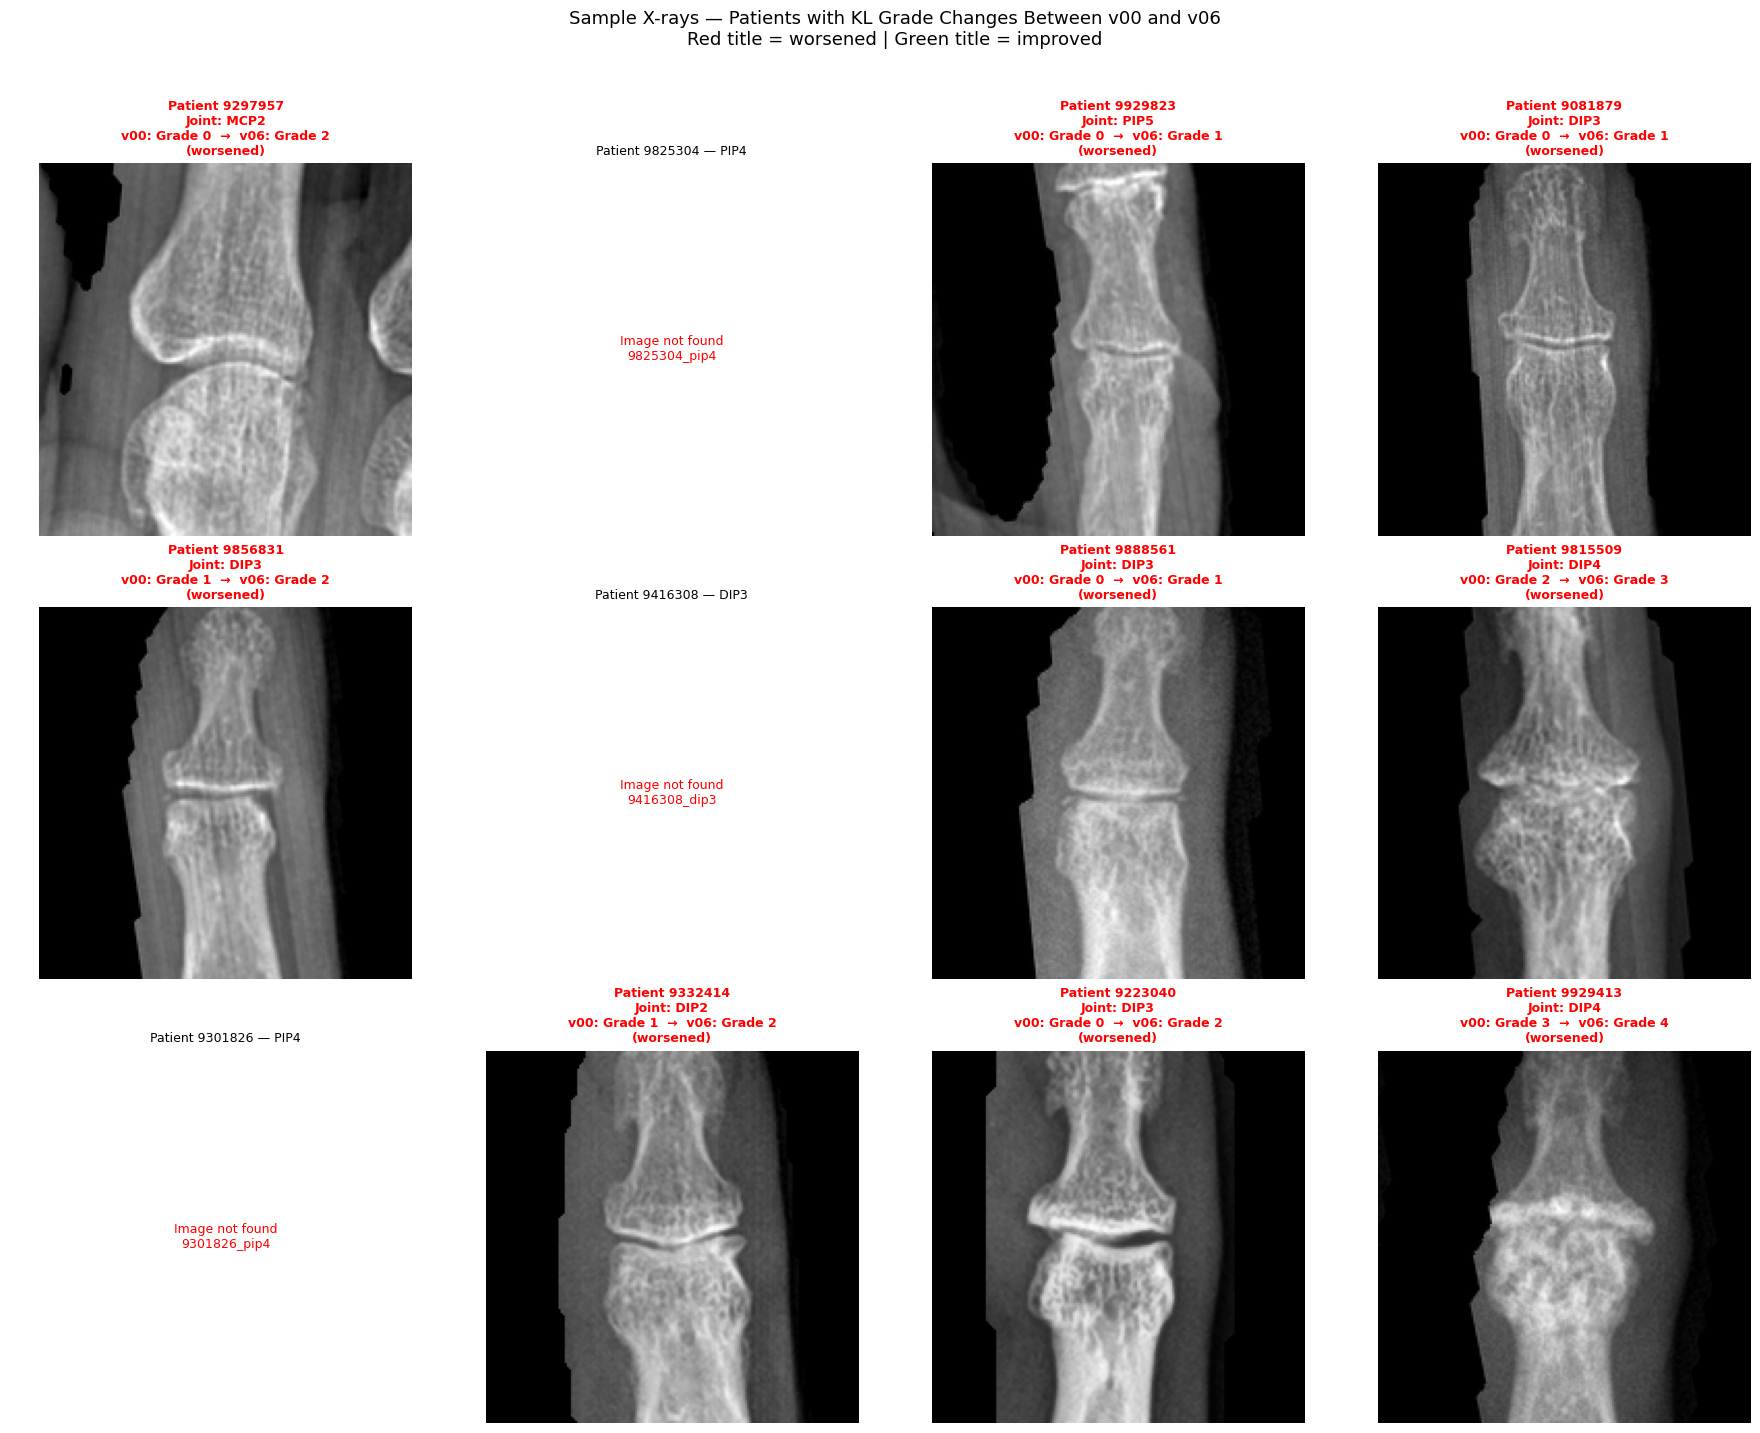

Chart saved to reports/
Available grade transitions in your data:
       transition  count
Grade 0 → Grade 1    329
Grade 0 → Grade 2    149
Grade 0 → Grade 3      6
Grade 1 → Grade 0     35
Grade 1 → Grade 2    294
Grade 1 → Grade 3     10
Grade 1 → Grade 4      3
Grade 2 → Grade 0      7
Grade 2 → Grade 1     17
Grade 2 → Grade 3    237
Grade 2 → Grade 4     17
Grade 3 → Grade 2      2
Grade 3 → Grade 4     75
Grade 4 → Grade 2      1
Grade 4 → Grade 3      2
Showing patients: Grade 1 → Grade 2
Total such patients: 294


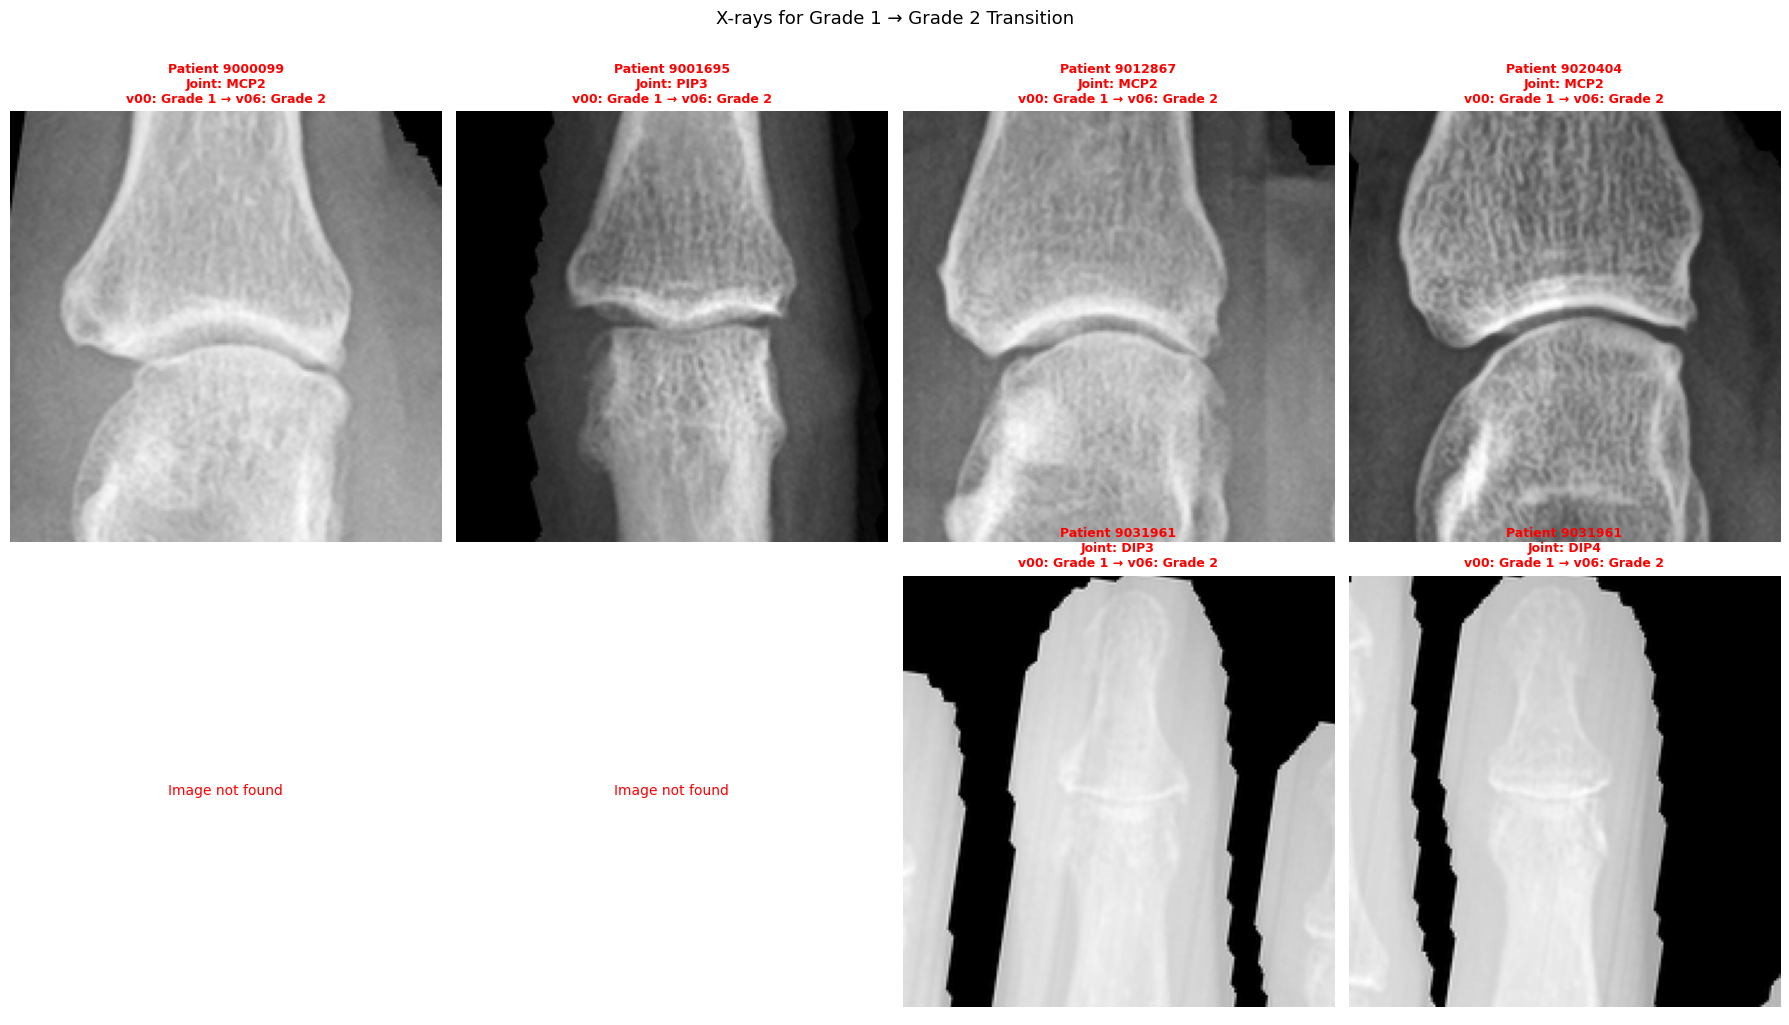

In [17]:
# Display images for patients whose KL grade changed
# Show v00 and v06 grades side by side for each joint that changed

import random

# Pick a sample of changed patients to display
sample_changes = changes_df.sample(min(12, len(changes_df)), 
                                    random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(3, 4, figsize=(18, 14))
axes = axes.flatten()

for i, (_, row) in enumerate(sample_changes.iterrows()):
    patient_id = str(row['patient_id'])
    joint      = row['joint'].lower()
    v00_grade  = int(row['v00_grade'])
    v06_grade  = int(row['v06_grade'])
    direction  = row['direction']
    
    img_path = os.path.join(IMAGE_DIR, f'{patient_id}_{joint}.png')
    
    ax = axes[i]
    
    if os.path.exists(img_path):
        img = Image.open(img_path).convert('L')
        ax.imshow(img, cmap='gray')
        
        # Color title based on direction
        title_color = 'red' if direction == 'worsened' else 'green'
        
        ax.set_title(
            f'Patient {patient_id}\n'
            f'Joint: {joint.upper()}\n'
            f'v00: Grade {v00_grade}  →  v06: Grade {v06_grade}\n'
            f'({direction})',
            fontsize=9,
            fontweight='bold',
            color=title_color
        )
    else:
        ax.text(0.5, 0.5, f'Image not found\n{patient_id}_{joint}',
                ha='center', va='center',
                transform=ax.transAxes,
                fontsize=9, color='red')
        ax.set_title(f'Patient {patient_id} — {joint.upper()}',
                     fontsize=9)
    
    ax.axis('off')

plt.suptitle(
    'Sample X-rays — Patients with KL Grade Changes Between v00 and v06\n'
    'Red title = worsened | Green title = improved',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'changed_patients_sample.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved to reports/")
# Show more detail — display by specific grade transition
# e.g. all patients that went from grade 1 to grade 2

print("Available grade transitions in your data:")
transitions = changes_df.groupby(['v00_grade', 'v06_grade']).size().reset_index()
transitions.columns = ['v00_grade', 'v06_grade', 'count']
transitions['transition'] = transitions.apply(
    lambda x: f"Grade {int(x['v00_grade'])} → Grade {int(x['v06_grade'])}", axis=1
)
print(transitions[['transition', 'count']].to_string(index=False))
# Display images for a specific grade transition
# Change these two values to explore different transitions
FROM_GRADE = 1
TO_GRADE   = 2

# Filter for this specific transition
transition_patients = changes_df[
    (changes_df['v00_grade'] == FROM_GRADE) &
    (changes_df['v06_grade'] == TO_GRADE)
].head(8).reset_index(drop=True)

print(f"Showing patients: Grade {FROM_GRADE} → Grade {TO_GRADE}")
print(f"Total such patients: {len(changes_df[(changes_df['v00_grade'] == FROM_GRADE) & (changes_df['v06_grade'] == TO_GRADE)])}")

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, (_, row) in enumerate(transition_patients.iterrows()):
    patient_id = str(row['patient_id'])
    joint      = row['joint'].lower()
    
    img_path = os.path.join(IMAGE_DIR, f'{patient_id}_{joint}.png')
    ax       = axes[i]
    
    if os.path.exists(img_path):
        img = Image.open(img_path).convert('L')
        ax.imshow(img, cmap='gray')
        ax.set_title(
            f'Patient {patient_id}\n'
            f'Joint: {joint.upper()}\n'
            f'v00: Grade {FROM_GRADE} → v06: Grade {TO_GRADE}',
            fontsize=9, fontweight='bold', color='red'
        )
    else:
        ax.text(0.5, 0.5, 'Image not found',
                ha='center', va='center',
                transform=ax.transAxes, color='red')
    
    ax.axis('off')

# Hide unused subplots
for j in range(len(transition_patients), len(axes)):
    axes[j].axis('off')

plt.suptitle(
    f'X-rays for Grade {FROM_GRADE} → Grade {TO_GRADE} Transition',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig(
    os.path.join(REPORTS_DIR, f'transition_{FROM_GRADE}_to_{TO_GRADE}.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()


In [20]:
# Get patients whose KL grade changed for DIP joints only
DIP_JOINTS = ['dip2', 'dip3', 'dip4', 'dip5']

DIP_COLS_PAIRS = {
    'dip2': ('v00DIP2_KL', 'v06DIP2_KL'),
    'dip3': ('v00DIP3_KL', 'v06DIP3_KL'),
    'dip4': ('v00DIP4_KL', 'v06DIP4_KL'),
    'dip5': ('v00DIP5_KL', 'v06DIP5_KL'),
}

dip_changes = []

for _, row in df.iterrows():
    patient_id = str(int(row['id']))
    
    for joint, (v00_col, v06_col) in DIP_COLS_PAIRS.items():
        v00_grade = row[v00_col]
        v06_grade = row[v06_col]
        
        # Skip if either grade is missing
        if pd.isna(v00_grade) or pd.isna(v06_grade):
            continue
        
        # Only include if grade changed
        if v00_grade != v06_grade:
            dip_changes.append({
                'patient_id' : patient_id,
                'joint'      : joint.upper(),
                'v00_grade'  : int(v00_grade),
                'v06_grade'  : int(v06_grade),
                'direction'  : 'worsened' if v06_grade > v00_grade else 'improved',
                'change'     : int(v06_grade - v00_grade)
            })

dip_changes_df = pd.DataFrame(dip_changes)

print(f"Total DIP joint grade changes : {len(dip_changes_df)}")
print(f"\nBreakdown per joint:")
print(dip_changes_df['joint'].value_counts().sort_index())

print(f"\nDirection of changes:")
print(dip_changes_df['direction'].value_counts())

print(f"\nChange magnitude:")
print(dip_changes_df['change'].value_counts().sort_index())
# Show the actual v00 and v06 scores per patient per DIP joint
print(f"── DIP Joint KL Score Changes ─────────────────────────────")
print(f"\n{'Patient ID':<12} | {'Joint':<6} | {'v00 Grade':>10} | "
      f"{'v06 Grade':>10} | {'Direction':>10} | {'Change':>7}")
print("-" * 65)

for _, row in dip_changes_df.iterrows():
    print(f"{row['patient_id']:<12} | {row['joint']:<6} | "
          f"{row['v00_grade']:>10} | {row['v06_grade']:>10} | "
          f"{row['direction']:>10} | {row['change']:>+7}")
# Summary table — count of each grade transition per DIP joint
print("── Grade Transition Summary per DIP Joint ─────────────")

for joint in ['DIP2', 'DIP3', 'DIP4', 'DIP5']:
    joint_df = dip_changes_df[dip_changes_df['joint'] == joint]
    print(f"\n{joint} — {len(joint_df)} changes:")
    print(f"  {'From → To':<15} | {'Count':>6} | {'Direction':>10}")
    print(f"  {'-'*37}")
    transitions = joint_df.groupby(
        ['v00_grade', 'v06_grade', 'direction']
    ).size().reset_index(name='count')
    for _, t in transitions.iterrows():
        print(f"  Grade {int(t['v00_grade'])} → Grade {int(t['v06_grade']):<5} | "
              f"{int(t['count']):>6} | {t['direction']:>10}")
# Save to CSV for inspection in Excel
save_path = os.path.join(SPLITS_DIR, 'dip_changed_patients_kl_scores.csv')
dip_changes_df.to_csv(save_path, index=False)

print(f"Saved to : {save_path}")
print(f"Shape    : {dip_changes_df.shape}")
print(f"\nFirst 10 rows:")
print(dip_changes_df.head(10).to_string(index=False))


Total DIP joint grade changes : 744

Breakdown per joint:
joint
DIP2    233
DIP3    220
DIP4    132
DIP5    159
Name: count, dtype: int64

Direction of changes:
direction
worsened    705
improved     39
Name: count, dtype: int64

Change magnitude:
change
-2      4
-1     35
 1    603
 2    101
 3      1
Name: count, dtype: int64
── DIP Joint KL Score Changes ─────────────────────────────

Patient ID   | Joint  |  v00 Grade |  v06 Grade |  Direction |  Change
-----------------------------------------------------------------
9002316      | DIP2   |          0 |          2 |   worsened |      +2
9003126      | DIP2   |          0 |          1 |   worsened |      +1
9006140      | DIP5   |          2 |          3 |   worsened |      +1
9009927      | DIP3   |          3 |          4 |   worsened |      +1
9009927      | DIP4   |          2 |          3 |   worsened |      +1
9009957      | DIP3   |          0 |          1 |   worsened |      +1
9014209      | DIP2   |          2 |         

In [21]:
#Per-joint distribution with all five grads for dip, pip and mcp2 for v00 only
FINAL_JOINTS = ['dip2', 'dip3', 'dip4', 'dip5',
                'pip3', 'pip4', 'pip5', 'mcp2']

KL_COLS_MAP = {
    'dip2': 'v00DIP2_KL', 'dip3': 'v00DIP3_KL',
    'dip4': 'v00DIP4_KL', 'dip5': 'v00DIP5_KL',
    'pip3': 'v00PIP3_KL', 'pip4': 'v00PIP4_KL',
    'pip5': 'v00PIP5_KL', 'mcp2': 'v00MCP2_KL',
}

print("── Per joint grade distribution (5 classes) ───────────────")
print(f"{'Joint':<8} | {'G0':>6} | {'G1':>6} | {'G2':>6} | "
      f"{'G3':>6} | {'G4':>6} | {'Imbalance':>10}")
print("-" * 65)

for joint in FINAL_JOINTS:
    col    = KL_COLS_MAP[joint]
    counts = df[col].value_counts().sort_index().dropna()
    g0 = int(counts.get(0.0, counts.get(0, 0)))
    g1 = int(counts.get(1.0, counts.get(1, 0)))
    g2 = int(counts.get(2.0, counts.get(2, 0)))
    g3 = int(counts.get(3.0, counts.get(3, 0)))
    g4 = int(counts.get(4.0, counts.get(4, 0)))
    
    # Imbalance against smallest non-zero grade
    non_zero = [c for c in [g0,g1,g2,g3,g4] if c > 0]
    ratio = max(non_zero) / min(non_zero) if non_zero else float('inf')
    
    print(f"{joint.upper():<8} | {g0:>6} | {g1:>6} | {g2:>6} | "
          f"{g3:>6} | {g4:>6} | {ratio:>9.1f}x")

print(f"\nTotal grade 3 samples : {sum(int(df[col].value_counts().get(3.0, df[col].value_counts().get(3, 0))) for col in KL_COLS_MAP.values())}")
print(f"Total grade 4 samples : {sum(int(df[col].value_counts().get(4.0, df[col].value_counts().get(4, 0))) for col in KL_COLS_MAP.values())}")

── Per joint grade distribution (5 classes) ───────────────
Joint    |     G0 |     G1 |     G2 |     G3 |     G4 |  Imbalance
-----------------------------------------------------------------
DIP2     |   1911 |    447 |    996 |    173 |     63 |      30.3x
DIP3     |   2251 |    408 |    744 |    129 |     53 |      42.5x
DIP4     |   2516 |    386 |    556 |     98 |     29 |      86.8x
DIP5     |   1897 |    580 |    869 |    197 |     31 |      61.2x
PIP3     |   2368 |    588 |    556 |     62 |     14 |     169.1x
PIP4     |   2182 |    847 |    501 |     39 |     15 |     145.5x
PIP5     |   2576 |    461 |    494 |     41 |     10 |     257.6x
MCP2     |   3145 |    228 |    181 |     23 |     13 |     241.9x

Total grade 3 samples : 762
Total grade 4 samples : 228


In [23]:
# New joint selection — DIP joints only for master-dataset and split based on that
FINAL_JOINTS_NEW = ['dip2', 'dip3', 'dip4', 'dip5']

KL_COLS_MAP_NEW = {
    'dip2': 'v00DIP2_KL',
    'dip3': 'v00DIP3_KL',
    'dip4': 'v00DIP4_KL',
    'dip5': 'v00DIP5_KL',
}

# Check distribution for 5 classes across DIP joints only
print("── DIP Joints — 5 Class Distribution ─────────────────────")
print(f"{'Joint':<8} | {'G0':>6} | {'G1':>6} | {'G2':>6} | "
      f"{'G3':>6} | {'G4':>6} | {'Total':>7} | {'Imbalance':>10}")
print("-" * 72)

total_per_grade = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0}

for joint in FINAL_JOINTS_NEW:
    col    = KL_COLS_MAP_NEW[joint]
    counts = df[col].value_counts().sort_index().dropna()
    g0 = int(counts.get(0.0, counts.get(0, 0)))
    g1 = int(counts.get(1.0, counts.get(1, 0)))
    g2 = int(counts.get(2.0, counts.get(2, 0)))
    g3 = int(counts.get(3.0, counts.get(3, 0)))
    g4 = int(counts.get(4.0, counts.get(4, 0)))
    total  = g0 + g1 + g2 + g3 + g4
    non_zero = [c for c in [g0,g1,g2,g3,g4] if c > 0]
    ratio  = max(non_zero) / min(non_zero) if non_zero else float('inf')

    total_per_grade[0] += g0
    total_per_grade[1] += g1
    total_per_grade[2] += g2
    total_per_grade[3] += g3
    total_per_grade[4] += g4

    print(f"{joint.upper():<8} | {g0:>6} | {g1:>6} | {g2:>6} | "
          f"{g3:>6} | {g4:>6} | {total:>7} | {ratio:>9.1f}x")

print("-" * 72)
total_all = sum(total_per_grade.values())
ratio_all = max(total_per_grade.values()) / min(total_per_grade.values())
print(f"{'TOTAL':<8} | {total_per_grade[0]:>6} | {total_per_grade[1]:>6} | "
      f"{total_per_grade[2]:>6} | {total_per_grade[3]:>6} | "
      f"{total_per_grade[4]:>6} | {total_all:>7} | {ratio_all:>9.1f}x")

print(f"\nExpected samples after filtering : ~{total_all}")
# Show split estimates
print("── Estimated split sizes ──────────────────────────")
print(f"Total samples    : {total_all}")
print(f"Train (70%)      : ~{int(total_all * 0.70):,}")
print(f"Val   (15%)      : ~{int(total_all * 0.15):,}")
print(f"Test  (15%)      : ~{int(total_all * 0.15):,}")

print(f"\n── Estimated grade 4 samples per split ────────────")
g4_total = total_per_grade[4]
print(f"Grade 4 total    : {g4_total}")
print(f"Grade 4 train    : ~{int(g4_total * 0.70)}")
print(f"Grade 4 val      : ~{int(g4_total * 0.15)}")
print(f"Grade 4 test     : ~{int(g4_total * 0.15)}")
print(f"\nImbalance ratio  : {ratio_all:.1f}x")

── DIP Joints — 5 Class Distribution ─────────────────────
Joint    |     G0 |     G1 |     G2 |     G3 |     G4 |   Total |  Imbalance
------------------------------------------------------------------------
DIP2     |   1911 |    447 |    996 |    173 |     63 |    3590 |      30.3x
DIP3     |   2251 |    408 |    744 |    129 |     53 |    3585 |      42.5x
DIP4     |   2516 |    386 |    556 |     98 |     29 |    3585 |      86.8x
DIP5     |   1897 |    580 |    869 |    197 |     31 |    3574 |      61.2x
------------------------------------------------------------------------
TOTAL    |   8575 |   1821 |   3165 |    597 |    176 |   14334 |      48.7x

Expected samples after filtering : ~14334
── Estimated split sizes ──────────────────────────
Total samples    : 14334
Train (70%)      : ~10,033
Val   (15%)      : ~2,150
Test  (15%)      : ~2,150

── Estimated grade 4 samples per split ────────────
Grade 4 total    : 176
Grade 4 train    : ~123
Grade 4 val      : ~26
Grade 4 tes

In [25]:
# Samples per joint per KL grade with train/val/test estimates DIp joints only
print("── Estimated Training Samples per Joint per KL Grade ──────────────────")
print(f"{'Joint':<8} | {'Grade':>6} | {'Total':>7} | "
      f"{'Train(70%)':>11} | {'Val(15%)':>9} | {'Test(15%)':>9}")
print("-" * 60)

for joint in FINAL_JOINTS_NEW:
    col    = KL_COLS_MAP_NEW[joint]
    counts = df[col].value_counts().sort_index().dropna()
    
    for grade in [0, 1, 2, 3, 4]:
        count = int(counts.get(float(grade), counts.get(grade, 0)))
        train = int(count * 0.70)
        val   = int(count * 0.15)
        test  = int(count * 0.15)
        
        print(f"{joint.upper():<8} | {grade:>6} | {count:>7} | "
              f"{train:>11} | {val:>9} | {test:>9}")
    
    print("-" * 60)
    # Summary — total training samples per grade across all DIP joints
print("── Total Training Samples per KL Grade (All DIP Joints) ──")
print(f"{'Grade':<8} | {'Total':>7} | {'Train(70%)':>11} | "
      f"{'Val(15%)':>9} | {'Test(15%)':>9} | {'% of Train':>11}")
print("-" * 65)

grade_totals = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0}

for joint in FINAL_JOINTS_NEW:
    col    = KL_COLS_MAP_NEW[joint]
    counts = df[col].value_counts().sort_index().dropna()
    for grade in [0, 1, 2, 3, 4]:
        count = int(counts.get(float(grade), counts.get(grade, 0)))
        grade_totals[grade] += count

total_all = sum(grade_totals.values())

for grade, count in grade_totals.items():
    train  = int(count * 0.70)
    val    = int(count * 0.15)
    test   = int(count * 0.15)
    pct    = train / int(total_all * 0.70) * 100
    print(f"Grade {grade}  | {count:>7} | {train:>11} | "
          f"{val:>9} | {test:>9} | {pct:>10.1f}%")

print("-" * 65)
print(f"{'TOTAL':<8} | {total_all:>7} | {int(total_all*0.70):>11} | "
      f"{int(total_all*0.15):>9} | {int(total_all*0.15):>9} |")

── Estimated Training Samples per Joint per KL Grade ──────────────────
Joint    |  Grade |   Total |  Train(70%) |  Val(15%) | Test(15%)
------------------------------------------------------------
DIP2     |      0 |    1911 |        1337 |       286 |       286
DIP2     |      1 |     447 |         312 |        67 |        67
DIP2     |      2 |     996 |         697 |       149 |       149
DIP2     |      3 |     173 |         121 |        25 |        25
DIP2     |      4 |      63 |          44 |         9 |         9
------------------------------------------------------------
DIP3     |      0 |    2251 |        1575 |       337 |       337
DIP3     |      1 |     408 |         285 |        61 |        61
DIP3     |      2 |     744 |         520 |       111 |       111
DIP3     |      3 |     129 |          90 |        19 |        19
DIP3     |      4 |      53 |          37 |         7 |         7
------------------------------------------------------------
DIP4     |      0 |

In [26]:
# Rebuild master dataset — DIP joints only, 5 KL classes, no merging
FINAL_JOINTS_NEW = ['dip2', 'dip3', 'dip4', 'dip5']

KL_COLS_MAP_NEW = {
    'dip2': 'v00DIP2_KL',
    'dip3': 'v00DIP3_KL',
    'dip4': 'v00DIP4_KL',
    'dip5': 'v00DIP5_KL',
}

valid_samples_new = []

for _, row in df.iterrows():
    patient_id = str(int(row['id']))

    if patient_id not in patients_with_images:
        continue

    for joint in FINAL_JOINTS_NEW:
        kl_col   = KL_COLS_MAP_NEW[joint]
        kl_grade = row[kl_col]
        img_path = os.path.join(IMAGE_DIR, f'{patient_id}_{joint}.png')

        if os.path.exists(img_path) and not pd.isna(kl_grade):
            valid_samples_new.append({
                'patient_id' : patient_id,
                'joint'      : joint,
                'kl_grade'   : int(kl_grade),
                'image_path' : img_path
            })

valid_df_new = pd.DataFrame(valid_samples_new)

print(f"── New master dataset summary ─────────────────────")
print(f"Total samples     : {len(valid_df_new):,}")
print(f"Joints            : {FINAL_JOINTS_NEW}")
print(f"Unique patients   : {valid_df_new['patient_id'].nunique()}")

print(f"\nGrade distribution:")
counts = valid_df_new['kl_grade'].value_counts().sort_index()
total  = len(valid_df_new)
for grade, count in counts.items():
    pct = count / total * 100
    bar = '█' * int(pct / 2)
    print(f"  Grade {grade} : {count:>6} ({pct:>5.1f}%)  {bar}")

print(f"\nImbalance ratio   : {counts.max()/counts.min():.1f}x")
print(f"\nSamples per joint:")
print(valid_df_new['joint'].value_counts().sort_index())
# Save new master dataset — overwrites the old one
save_path = os.path.join(SPLITS_DIR, 'master_dataset.csv')
valid_df_new.to_csv(save_path, index=False)

print(f"master_dataset.csv saved successfully")
print(f"Shape    : {valid_df_new.shape}")
print(f"Columns  : {valid_df_new.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(valid_df_new.head())
# Update master setup variables to reflect new decisions
valid_df     = valid_df_new.copy()
FINAL_JOINTS = FINAL_JOINTS_NEW.copy()
KL_COLS_MAP  = KL_COLS_MAP_NEW.copy()
N_CLASSES    = 5

print(f"Variables updated:")
print(f"  FINAL_JOINTS : {FINAL_JOINTS}")
print(f"  N_CLASSES    : {N_CLASSES}")
print(f"  valid_df     : {valid_df.shape}")

── New master dataset summary ─────────────────────
Total samples     : 13,200
Joints            : ['dip2', 'dip3', 'dip4', 'dip5']
Unique patients   : 3505

Grade distribution:
  Grade 0 :   8494 ( 64.3%)  ████████████████████████████████
  Grade 1 :   1774 ( 13.4%)  ██████
  Grade 2 :   2546 ( 19.3%)  █████████
  Grade 3 :    215 (  1.6%)  
  Grade 4 :    171 (  1.3%)  

Imbalance ratio   : 49.7x

Samples per joint:
joint
dip2    3238
dip3    3317
dip4    3395
dip5    3250
Name: count, dtype: int64
master_dataset.csv saved successfully
Shape    : (13200, 4)
Columns  : ['patient_id', 'joint', 'kl_grade', 'image_path']

First 5 rows:
  patient_id joint  kl_grade  \
0    9000099  dip2         0   
1    9000099  dip3         1   
2    9000099  dip4         1   
3    9000099  dip5         1   
4    9000296  dip2         2   

                                          image_path  
0  C:\Users\snime\OneDrive\Documents\my transciri...  
1  C:\Users\snime\OneDrive\Documents\my transciri...  


In [28]:
# splitting pipeline for master dataset using DIP joints only V00
from sklearn.model_selection import train_test_split

# Load fresh master dataset
valid_df = pd.read_csv(os.path.join(SPLITS_DIR, 'master_dataset.csv'))

# Patient level split
unique_patients = valid_df['patient_id'].unique()
print(f"Total unique patients : {len(unique_patients)}")

# Split off test set (15%)
train_val_patients, test_patients = train_test_split(
    unique_patients, test_size=0.15, random_state=42
)

# Split remaining into train (70%) and val (15%)
val_size = 0.15 / (0.70 + 0.15)
train_patients, val_patients = train_test_split(
    train_val_patients, test_size=val_size, random_state=42
)

# Assign rows based on patient ID
train_df = valid_df[valid_df['patient_id'].isin(train_patients)].reset_index(drop=True)
val_df   = valid_df[valid_df['patient_id'].isin(val_patients)].reset_index(drop=True)
test_df  = valid_df[valid_df['patient_id'].isin(test_patients)].reset_index(drop=True)

print(f"\nPatient split:")
print(f"  Train : {len(train_patients):,} patients → {len(train_df):,} samples")
print(f"  Val   : {len(val_patients):,} patients → {len(val_df):,} samples")
print(f"  Test  : {len(test_patients):,} patients → {len(test_df):,} samples")
print(f"  Total : {len(train_df)+len(val_df)+len(test_df):,} samples")

Total unique patients : 3505

Patient split:
  Train : 2,453 patients → 9,280 samples
  Val   : 526 patients → 1,940 samples
  Test  : 526 patients → 1,980 samples
  Total : 13,200 samples


In [29]:
# Verify no data leakage
train_ids = set(train_df['patient_id'].unique())
val_ids   = set(val_df['patient_id'].unique())
test_ids  = set(test_df['patient_id'].unique())

print("── Data leakage check ─────────────────────────────")
print(f"Train ∩ Val  : {len(train_ids.intersection(val_ids))}  "
      f"{'✓ No leakage' if len(train_ids.intersection(val_ids)) == 0 else '✗ LEAKAGE'}")
print(f"Train ∩ Test : {len(train_ids.intersection(test_ids))}  "
      f"{'✓ No leakage' if len(train_ids.intersection(test_ids)) == 0 else '✗ LEAKAGE'}")
print(f"Val ∩ Test   : {len(val_ids.intersection(test_ids))}  "
      f"{'✓ No leakage' if len(val_ids.intersection(test_ids)) == 0 else '✗ LEAKAGE'}")

── Data leakage check ─────────────────────────────
Train ∩ Val  : 0  ✓ No leakage
Train ∩ Test : 0  ✓ No leakage
Val ∩ Test   : 0  ✓ No leakage


In [30]:

#Per joint counts DIP only
print("── EXACT Samples per Joint per Grade ──────────────────────────")
print(f"{'Joint':<8} | {'Grade':>6} | {'Train':>7} | {'Val':>7} | {'Test':>7}")
print("-" * 45)

for joint in FINAL_JOINTS:
    for grade in [0, 1, 2, 3, 4]:
        t  = len(train_df[(train_df['joint'] == joint) & 
                          (train_df['kl_grade'] == grade)])
        v  = len(val_df[(val_df['joint'] == joint) & 
                        (val_df['kl_grade'] == grade)])
        te = len(test_df[(test_df['joint'] == joint) & 
                         (test_df['kl_grade'] == grade)])
        print(f"{joint.upper():<8} | {grade:>6} | {t:>7} | {v:>7} | {te:>7}")
    print("-" * 45)

── EXACT Samples per Joint per Grade ──────────────────────────
Joint    |  Grade |   Train |     Val |    Test
---------------------------------------------
DIP2     |      0 |    1351 |     266 |     274
DIP2     |      1 |     310 |      68 |      56
DIP2     |      2 |     541 |     121 |     131
DIP2     |      3 |      37 |       7 |      14
DIP2     |      4 |      41 |      10 |      11
---------------------------------------------
DIP3     |      0 |    1576 |     329 |     327
DIP3     |      1 |     275 |      59 |      59
DIP3     |      2 |     414 |      86 |      92
DIP3     |      3 |      33 |       7 |       8
DIP3     |      4 |      34 |       8 |      10
---------------------------------------------
DIP4     |      0 |    1777 |     357 |     363
DIP4     |      1 |     260 |      65 |      51
DIP4     |      2 |     305 |      75 |      81
DIP4     |      3 |      21 |       6 |       5
DIP4     |      4 |      18 |       4 |       7
------------------------------

In [31]:
#per grade totals DIP only
print("── EXACT Total per Grade — All DIP Joints ─────────────────")
print(f"{'Grade':<8} | {'Train':>7} | {'Val':>7} | {'Test':>7} | {'Total':>7}")
print("-" * 45)

for grade in [0, 1, 2, 3, 4]:
    t  = len(train_df[train_df['kl_grade'] == grade])
    v  = len(val_df[val_df['kl_grade'] == grade])
    te = len(test_df[test_df['kl_grade'] == grade])
    print(f"Grade {grade}  | {t:>7} | {v:>7} | {te:>7} | {t+v+te:>7}")

print("-" * 45)
print(f"{'TOTAL':<8} | {len(train_df):>7} | {len(val_df):>7} | "
      f"{len(test_df):>7} | {len(valid_df):>7}")

── EXACT Total per Grade — All DIP Joints ─────────────────
Grade    |   Train |     Val |    Test |   Total
---------------------------------------------
Grade 0  |    6044 |    1217 |    1233 |    8494
Grade 1  |    1230 |     284 |     260 |    1774
Grade 2  |    1759 |     379 |     408 |    2546
Grade 3  |     139 |      32 |      44 |     215
Grade 4  |     108 |      28 |      35 |     171
---------------------------------------------
TOTAL    |    9280 |    1940 |    1980 |   13200


In [32]:
# Save splits for DIP joints only 
train_df.to_csv(os.path.join(SPLITS_DIR, 'train.csv'), index=False)
val_df.to_csv(os.path.join(SPLITS_DIR,   'val.csv'),   index=False)
test_df.to_csv(os.path.join(SPLITS_DIR,  'test.csv'),  index=False)

print("── Splits saved ───────────────────────────────────")
print(f"  train.csv : {len(train_df):,} samples")
print(f"  val.csv   : {len(val_df):,} samples")
print(f"  test.csv  : {len(test_df):,} samples")
print(f"  Total     : {len(train_df)+len(val_df)+len(test_df):,} samples")

── Splits saved ───────────────────────────────────
  train.csv : 9,280 samples
  val.csv   : 1,940 samples
  test.csv  : 1,980 samples
  Total     : 13,200 samples


In [34]:
pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
   ---------------------------------------- 0.0/114.5 MB ? eta -:--:--
   - -------------------------------------- 5.2/114.5 MB 26.4 MB/s eta 0:00:05
   ----- ---------------------------------- 14.7/114.5 MB 37.6 MB/s eta 0:00:03
   --------- ------------------------------ 27.0/114.5 MB 43.9 MB/s eta 0:00:02
   -------------- ------------------------- 40.6/114.5 MB 48.9 MB/s eta 0:00:02
   ------------------ --------------------- 54.3/114.5 MB 51.6 MB/s eta 0:00:02
   ----------------------- ---------------- 67.1/114.5 MB 52.9 MB/s eta 0:00:01
   ---------------------------- ----------- 81.5/114.5 MB 54.9 MB/s eta 0:00:01
   --------------------------------- ------ 94.6/114.5 MB 55.7 MB/s eta 0:00:01
   ------------------------------------ -- 107.7/114.5 MB 56.4 MB/s eta 0:00:01
   --------------------------------------  114.3/114.5 MB 55.5 MB/s eta 0:00:01
   --------------------------------------  114.3/114.5 MB 55.5 MB/s eta 0

In [35]:
import importlib
import torch
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.11.0+cpu


In [36]:
#calcualte weights for training
import torch

# Calculate class weights from training set only
total_train  = len(train_df)
n_classes    = 5

train_counts = train_df['kl_grade'].value_counts().sort_index()

class_weights = torch.FloatTensor([
    total_train / (n_classes * train_counts[i])
    for i in range(n_classes)
])

print("── Class weights for training ─────────────────────")
for i, w in enumerate(class_weights):
    count = train_counts[i]
    print(f"  Grade {i} : {count:>5} samples → weight {w:.4f}")

print(f"\nclass_weights = {class_weights.tolist()}")
print("\nCopy these weights into your training script in Phase 2")

── Class weights for training ─────────────────────
  Grade 0 :  6044 samples → weight 0.3071
  Grade 1 :  1230 samples → weight 1.5089
  Grade 2 :  1759 samples → weight 1.0551
  Grade 3 :   139 samples → weight 13.3525
  Grade 4 :   108 samples → weight 17.1852

class_weights = [0.307081401348114, 1.5089430809020996, 1.055145025253296, 13.352518081665039, 17.185184478759766]

Copy these weights into your training script in Phase 2


In [ ]:
# Class weights for Phase 2 training — calculated from train.csv
# DO NOT recalculate from full dataset or val/test sets
#CLASS_WEIGHTS = [0.3071, 1.5089, 1.0551, 13.3525, 17.1852]

In [37]:
#  — Image size and pixel statistics
# Sample from training set only
sample_patients = train_df['patient_id'].sample(
    min(200, len(train_df['patient_id'].unique())),
    random_state=42
).astype(str).tolist()

widths, heights, means, stds = [], [], [], []
not_found = 0

for patient_id in sample_patients:
    for joint in FINAL_JOINTS:
        img_path = os.path.join(IMAGE_DIR, f'{patient_id}_{joint}.png')

        if not os.path.exists(img_path):
            not_found += 1
            continue

        img = np.array(Image.open(img_path).convert('L'))
        widths.append(img.shape[1])
        heights.append(img.shape[0])
        means.append(img.mean() / 255.0)
        stds.append(img.std() / 255.0)

print("── Image dimensions ────────────────────────────────")
print(f"Width  : min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.0f}")
print(f"Height : min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.0f}")

print("\n── Pixel statistics (normalized 0-1) ───────────────")
print(f"Mean : {np.mean(means):.4f}")
print(f"Std  : {np.mean(stds):.4f}")

print("\n── Copy these into preprocessing.py ────────────────")
print(f"DATASET_MEAN = {np.mean(means):.4f}")
print(f"DATASET_STD  = {np.mean(stds):.4f}")
print(f"\nFiles not found : {not_found}")

── Image dimensions ────────────────────────────────
Width  : min=180, max=180, mean=180
Height : min=180, max=180, mean=180

── Pixel statistics (normalized 0-1) ───────────────
Mean : 0.2361
Std  : 0.2095

── Copy these into preprocessing.py ────────────────
DATASET_MEAN = 0.2361
DATASET_STD  = 0.2095

Files not found : 14


SyntaxError: invalid syntax (2871652124.py, line 2)